In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00         SAO   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00         SAO   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00         SAO   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00         SAO   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00         SAO   
...               ...       ...        ...                  ...         ...   
14495830  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
14495831  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
14495832  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
14495833  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
14495834  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

          HourlyDewPointTemperature  HourlyDryBulbT

In [3]:
# Exclude days from April through October (months 4-10) in CV_rows
CV_rows = CV_rows[~CV_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_rows after removing April-October:", CV_rows.shape)

CV_rows after removing April-October: (6404926, 19)


In [4]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers

CV_filtered_rows = CV_rows[CV_rows["HourlyVisibility"] < 17.000]


print("CV_filtered_rows:", CV_filtered_rows.shape)

CV_filtered_rows: (4815127, 19)


In [5]:
CV_fog_rows = CV_filtered_rows[
    (CV_filtered_rows["HourlyVisibility"] < 1.000)
    & (CV_filtered_rows["HourlyPrecipitation"] < 0.03)
]

print("CV_fog_rows:", CV_fog_rows.shape)

CV_fog_rows: (263418, 19)


In [6]:
CV_fog_rows['HourlyDewpointDepression'] = (
    CV_fog_rows['HourlyDryBulbTemperature'] - CV_fog_rows['HourlyDewPointTemperature']
)

CV_fog_rows[['HourlyDryBulbTemperature', 'HourlyDewPointTemperature', 'HourlyDewpointDepression']].head()

,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlyDewpointDepression
6,11.9,11.9,0.0
7,11.9,11.9,0.0
8,11.9,11.9,0.0
9,11.9,11.9,0.0
10,13.5,12.4,1.1


In [7]:
negative_dewpoint_depressions = CV_fog_rows[
    CV_fog_rows["HourlyDewpointDepression"] < 0
].copy()

print("Rows with dewpoint depression < 0:", len(negative_dewpoint_depressions))
display(negative_dewpoint_depressions)

Rows with dewpoint depression < 0: 343


,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyPresentWeatherType,HourlySkyConditions,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION,HourlyDewpointDepression
1015723,USW00053125,36.73333,-119.80000,1933-12-26 02:00:00,WBO_F,1.7,1.4,0.0,||13,OVC:08,0.000,90.0,1.3,1933,12,26,2,0,FRESNO,-0.3
1015724,USW00053125,36.73333,-119.80000,1933-12-26 05:00:00,WBO_F,1.7,1.4,0.0,||13,NaN,0.000,90.0,1.3,1933,12,26,5,0,FRESNO,-0.3
1015728,USW00053125,36.73333,-119.80000,1933-12-27 02:00:00,WBO_F,2.2,2.1,0.0,||13,OVC:08,0.000,0.0,0.0,1933,12,27,2,0,FRESNO,-0.1
1015729,USW00053125,36.73333,-119.80000,1933-12-27 05:00:00,WBO_F,2.2,2.1,0.0,||13,NaN,0.000,0.0,0.0,1933,12,27,5,0,FRESNO,-0.1
1284921,USW00093193,36.78000,-119.71940,1974-11-28 07:00:00,SAO,2.2,2.1,0.0,||FG,OVC:08 0.00,0.000,0.0,0.0,1974,11,28,7,0,FRESNO YOSEMITE INTL,-0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11832141,USW00023232,38.50690,-121.49500,1978-12-23 05:00:00,SAO,12.2,1.1,0.0,||FG,NaN,0.805,180.0,1.5,1978,12,23,5,0,SACRAMENTO AP ASOS,-11.1
11990300,USW00023232,38.50690,-121.49500,1996-01-07 05:00:00,SAO,5.0,4.4,0.0,||FG FG,NaN,0.000,290.0,2.1,1996,1,7,5,0,SACRAMENTO AP ASOS,-0.6
12017686,USW00023232,38.50690,-121.49500,1997-11-25 07:50:00,FM-15,13.0,10.0,0.0,||FG FG,NaN,0.400,0.0,0.0,1997,11,25,7,50,SACRAMENTO AP ASOS,-3.0
12017824,USW00023232,38.50690,-121.49500,1997-11-28 07:00:00,FM-15,6.0,5.0,0.0,||FG,NaN,0.400,0.0,0.0,1997,11,28,7,0,SACRAMENTO AP ASOS,-1.0


In [8]:
CV_fog_rows["HourlyDewpointDepression"] = (
    CV_fog_rows["HourlyDewpointDepression"].clip(lower=0)
)

print(CV_fog_rows["HourlyDewpointDepression"].min())

0.0


In [9]:
# Remove outlier rows based on dewpoint depression using the IQR rule

dd_col = "HourlyDewpointDepression"

valid_dd = CV_fog_rows[dd_col].dropna()

q1 = valid_dd.quantile(0.25)
q3 = valid_dd.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

rows_before = len(CV_fog_rows)

CV_fog_rows = CV_fog_rows[
    CV_fog_rows[dd_col].between(lower_bound, upper_bound, inclusive="both")
].copy()

print(f"IQR bounds: {lower_bound:.3f} to {upper_bound:.3f} °C")
print(f"Rows before filtering: {rows_before}")
print(f"Rows after filtering: {len(CV_fog_rows)}")
print(f"Rows removed: {rows_before - len(CV_fog_rows)}")

IQR bounds: -1.500 to 2.500 °C
Rows before filtering: 263418
Rows after filtering: 239654
Rows removed: 23764


In [10]:
# Dewpoint depression for each fog observation (fog event row)
fog_events = CV_fog_rows.dropna(
    subset=["HourlyDryBulbTemperature", "HourlyDewPointTemperature"]
).copy()

fog_events["HourlyDewpointDepression"] = (
    fog_events["HourlyDryBulbTemperature"] - fog_events["HourlyDewPointTemperature"]
)

fog_events["DATE"] = pd.to_datetime(fog_events["DATE"], errors="coerce")
fog_events = fog_events.sort_values(["STATION", "DATE"])

fog_event_dd = fog_events[
    ["STATION", "DATE", "HourlyVisibility",
     "HourlyDryBulbTemperature", "HourlyDewPointTemperature",
     "HourlyDewpointDepression"]
]

print(fog_event_dd.head(20))
print("Total fog events with dewpoint depression:", len(fog_event_dd))

                STATION                DATE  HourlyVisibility  \
6109682  BAKERSFIELD AP 1930-01-23 07:00:00               0.0   
6109683  BAKERSFIELD AP 1930-01-23 08:00:00               0.0   
6109684  BAKERSFIELD AP 1930-01-23 09:00:00               0.0   
6109685  BAKERSFIELD AP 1930-01-23 10:00:00               0.8   
6109695  BAKERSFIELD AP 1930-01-24 07:00:00               0.0   
6109696  BAKERSFIELD AP 1930-01-24 08:00:00               0.0   
6109697  BAKERSFIELD AP 1930-01-24 09:00:00               0.0   
6109698  BAKERSFIELD AP 1930-01-24 10:00:00               0.2   
6109699  BAKERSFIELD AP 1930-01-24 11:00:00               0.8   
6109735  BAKERSFIELD AP 1930-01-27 08:00:00               0.8   
6109736  BAKERSFIELD AP 1930-01-27 09:00:00               0.4   
6110357  BAKERSFIELD AP 1930-03-15 07:00:00               0.4   
6115712  BAKERSFIELD AP 1930-11-28 05:00:00               0.8   
6115715  BAKERSFIELD AP 1930-11-28 08:00:00               0.8   
6115733  BAKERSFIELD AP 1

In [11]:
# filter out rows without both temperature and dewpoint values
CV_fog_rows = CV_fog_rows.dropna(subset=["HourlyDryBulbTemperature", "HourlyDewPointTemperature"])

monthly_station = (
    CV_fog_rows.groupby(["STATION", "year", "month"], as_index=False)["HourlyDewpointDepression"]
    .mean()
    .sort_values(["STATION", "year", "month"])
)


In [12]:
# Annual mean dewpoint depression by station/year
annual_station = (
    monthly_station.groupby(["STATION", "year"], as_index=False)["HourlyDewpointDepression"]
    .mean()
)

# Keep stations with >30 unique years of annual data
year_counts = annual_station.groupby("STATION")["year"].nunique()
eligible_stations_30 = year_counts[year_counts > 30].index

Total fog-event observations with dewpoint depression > 1 °C: 42307
          STATION  year  fog_events_gt1
0  BAKERSFIELD AP  1930               3
1  BAKERSFIELD AP  1931               7
2  BAKERSFIELD AP  1932               1
3  BAKERSFIELD AP  1934               2
4  BAKERSFIELD AP  1935               5


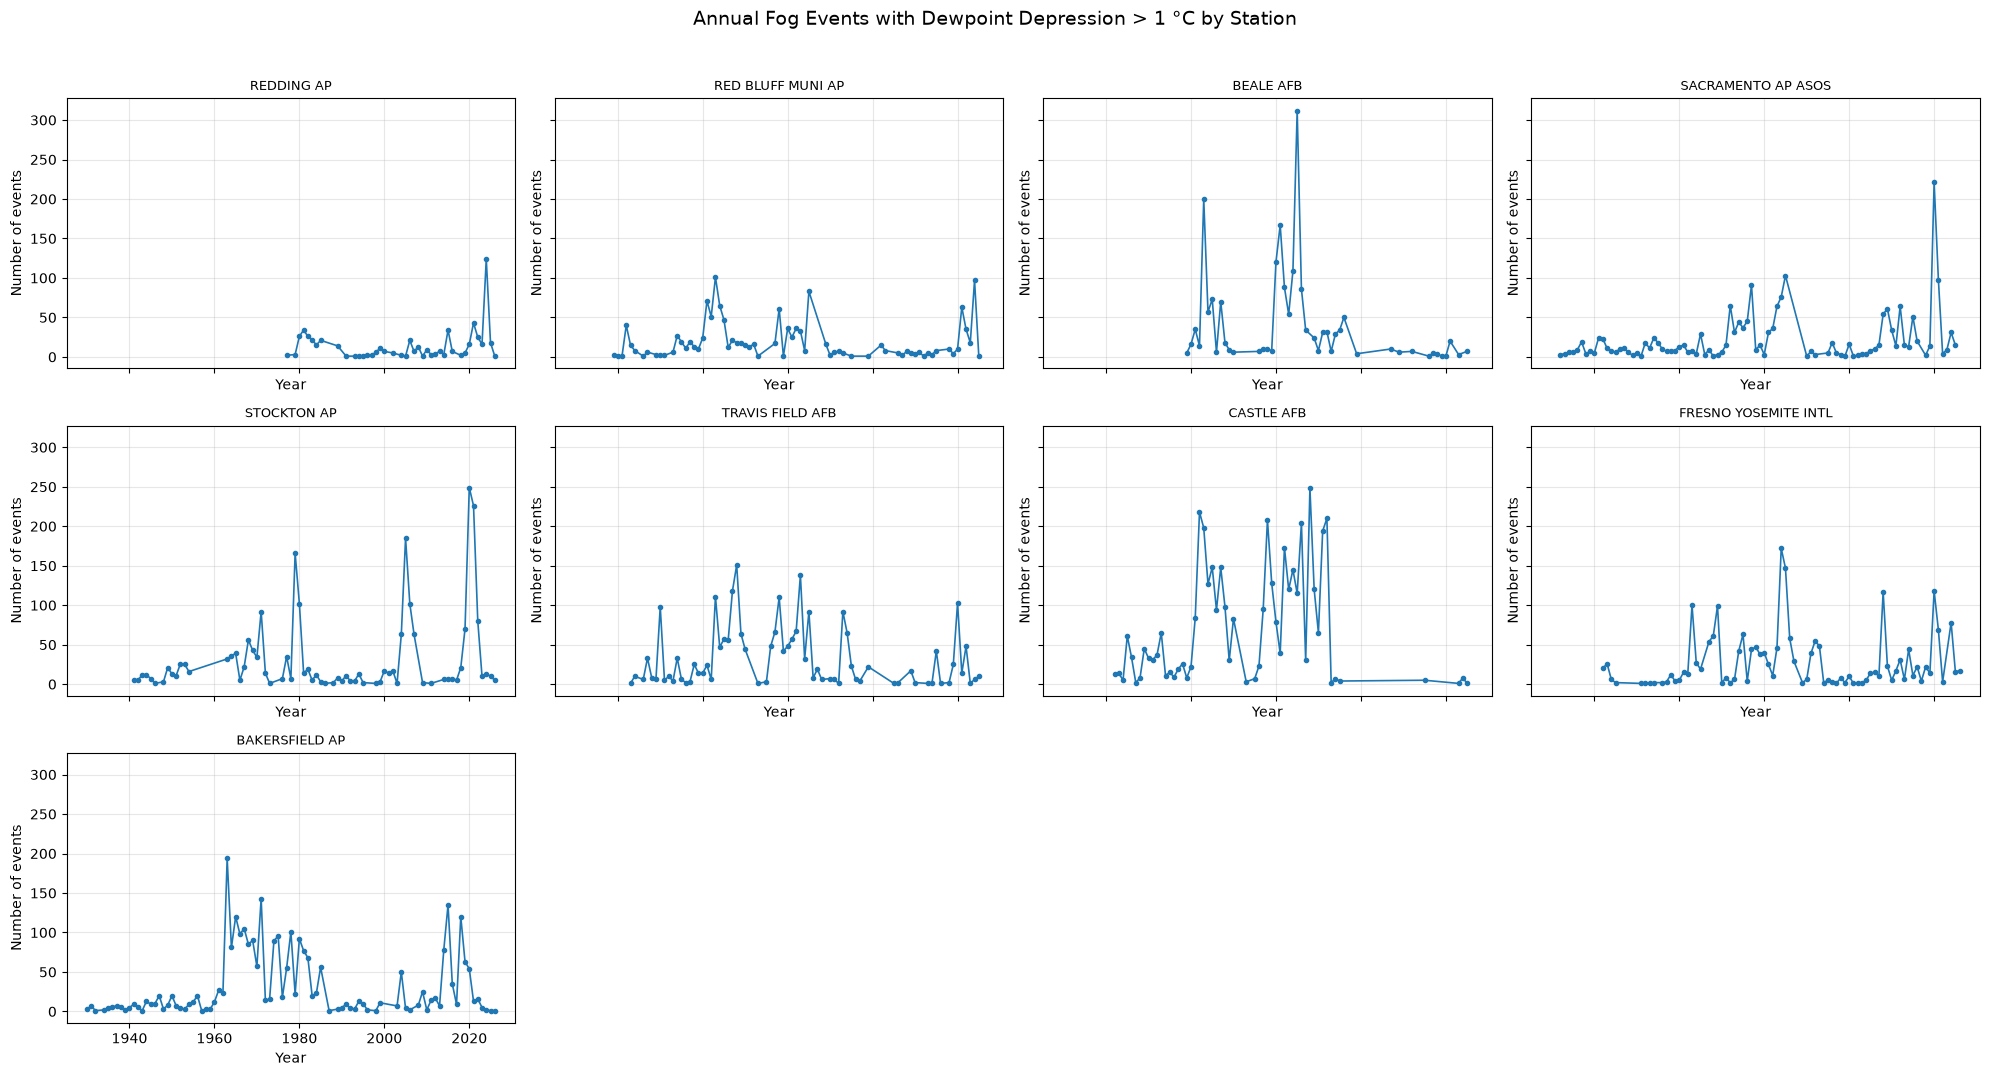

In [14]:
# Count fog-event observations with dewpoint depression > 1 °C
fog_events_gt1 = fog_event_dd.copy()
fog_events_gt1["DATE"] = pd.to_datetime(fog_events_gt1["DATE"], errors="coerce")
fog_events_gt1 = fog_events_gt1.dropna(
    subset=["DATE", "HourlyDewpointDepression"]
)

fog_events_gt1 = fog_events_gt1[
    fog_events_gt1["HourlyDewpointDepression"] > 1
].copy()

fog_events_gt1["year"] = fog_events_gt1["DATE"].dt.year

annual_events_gt1 = (
    fog_events_gt1.groupby(["STATION", "year"])
    .size()
    .reset_index(name="fog_events_gt1")
)

print("Total fog-event observations with dewpoint depression > 1 °C:",
      len(fog_events_gt1))
print(annual_events_gt1.head())

# Plot counts by year for each station
# stations = sorted(annual_events_gt1["STATION"].unique())
stations = ["REDDING AP", "RED BLUFF MUNI AP", "BEALE AFB", "SACRAMENTO AP ASOS", "STOCKTON AP", "TRAVIS FIELD AFB", "CASTLE AFB", "FRESNO YOSEMITE INTL", "BAKERSFIELD AP"]
ncols = 4
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)
axes = np.asarray(axes).reshape(-1)

for i, station in enumerate(stations):
    ax = axes[i]
    data = annual_events_gt1[
        annual_events_gt1["STATION"] == station
    ].sort_values("year")

    ax.plot(
        data["year"],
        data["fog_events_gt1"],
        marker="o",
        markersize=3,
        linewidth=1.2
    )
    ax.set_title(station, fontsize=9)
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of events")
    ax.grid(alpha=0.3)

for ax in axes[len(stations):]:
    ax.axis("off")

fig.suptitle(
    "Annual Fog Events with Dewpoint Depression > 1 °C by Station",
    y=1.02,
    fontsize=14
)
plt.tight_layout()
plt.show()

          STATION  year  fog_days_gt1
0  BAKERSFIELD AP  1930             3
1  BAKERSFIELD AP  1931             6
2  BAKERSFIELD AP  1932             1
3  BAKERSFIELD AP  1934             2
4  BAKERSFIELD AP  1935             4
Total fog days: 11836


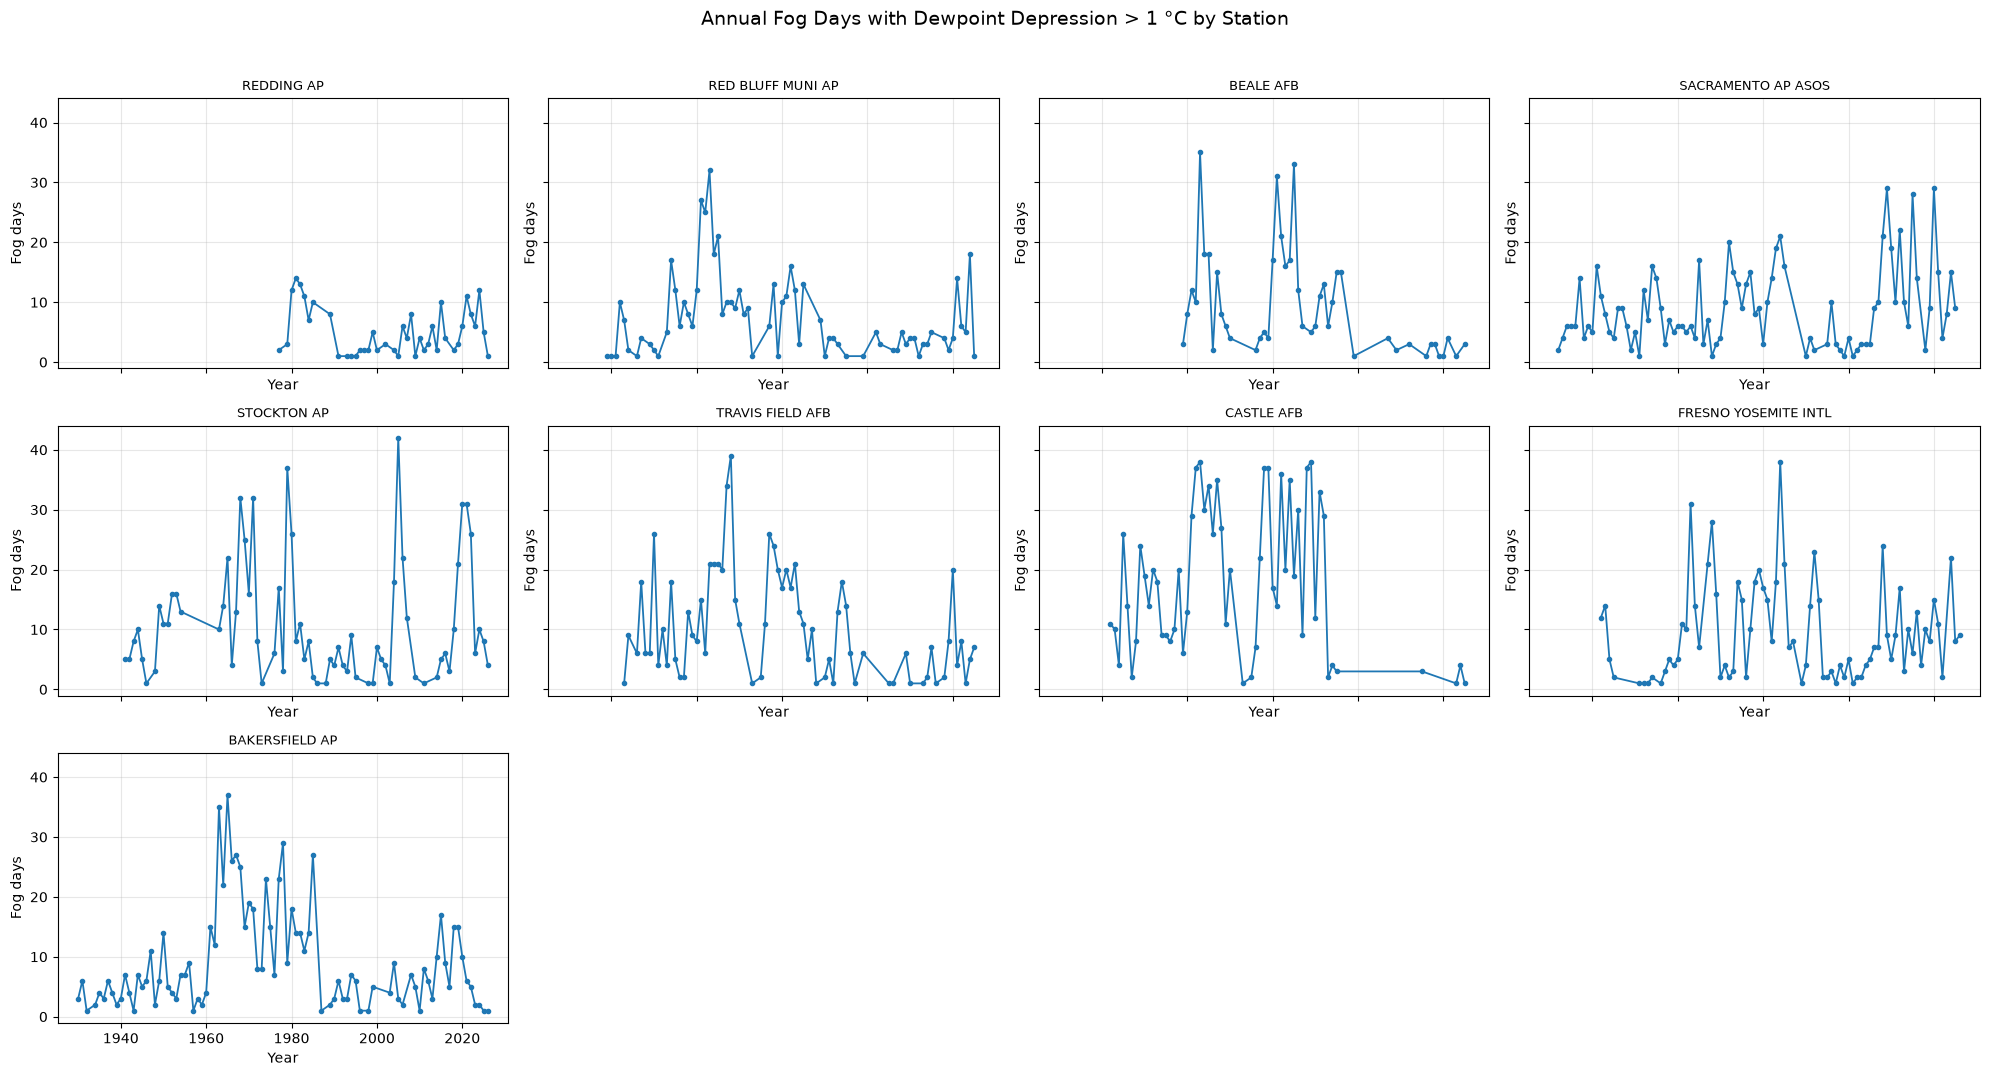

In [15]:
# Annual number of fog days with dewpoint depression > 1 °C by station

fog_days_gt1 = fog_event_dd.copy()
fog_days_gt1["DATE"] = pd.to_datetime(fog_days_gt1["DATE"], errors="coerce")

fog_days_gt1 = fog_days_gt1[
    (fog_days_gt1["HourlyDewpointDepression"] > 1)
    & fog_days_gt1["DATE"].notna()
].copy()

fog_days_gt1["year"] = fog_days_gt1["DATE"].dt.year
fog_days_gt1["fog_date"] = fog_days_gt1["DATE"].dt.normalize()

annual_fog_days_gt1 = (
    fog_days_gt1
    .drop_duplicates(["STATION", "fog_date"])
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_days_gt1"})
    .sort_values(["STATION", "year"])
)

print(annual_fog_days_gt1.head())
print("Total fog days:", annual_fog_days_gt1["fog_days_gt1"].sum())

stations_fog_days = ["REDDING AP", "RED BLUFF MUNI AP", "BEALE AFB", "SACRAMENTO AP ASOS", "STOCKTON AP", "TRAVIS FIELD AFB", "CASTLE AFB", "FRESNO YOSEMITE INTL", "BAKERSFIELD AP"]

if not stations_fog_days:
    print("No fog days found with dewpoint depression > 1 °C.")
else:
    ncols = 4
    nrows = int(np.ceil(len(stations_fog_days) / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.5 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.asarray(axes).reshape(-1)

    for i, station_name in enumerate(stations_fog_days):
        ax = axes[i]
        group = annual_fog_days_gt1[
            annual_fog_days_gt1["STATION"] == station_name
        ]

        ax.plot(
            group["year"],
            group["fog_days_gt1"],
            marker="o",
            markersize=3,
            linewidth=1.3
        )
        ax.set_title(station_name, fontsize=9)
        ax.set_xlabel("Year")
        ax.set_ylabel("Fog days")
        ax.grid(alpha=0.3)

    for ax in axes[len(stations_fog_days):]:
        ax.axis("off")

    fig.suptitle(
        "Annual Fog Days with Dewpoint Depression > 1 °C by Station",
        y=1.02,
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

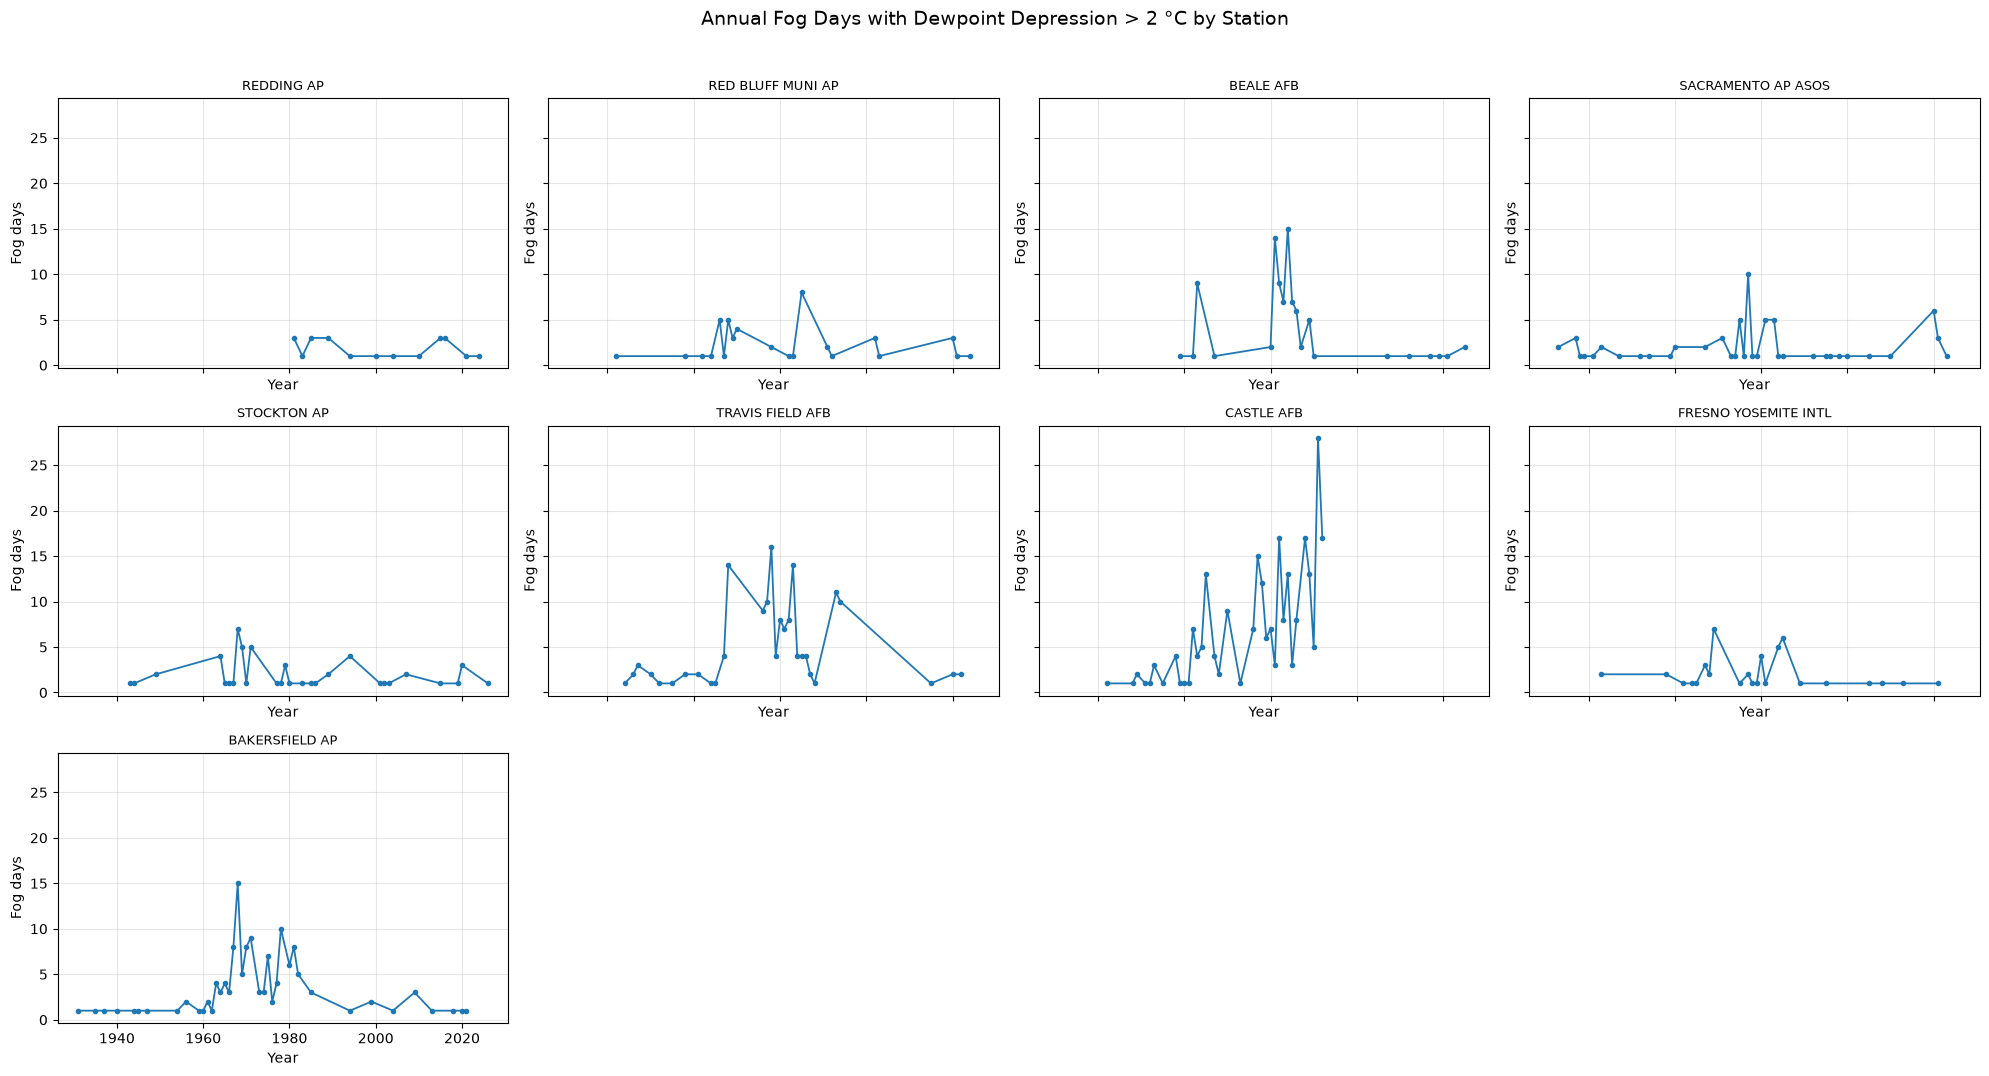

In [17]:
# Annual fog days with dewpoint depression > 2 °C by station

fog_days_gt2 = fog_event_dd.copy()
fog_days_gt2["DATE"] = pd.to_datetime(fog_days_gt2["DATE"], errors="coerce")

fog_days_gt2 = fog_days_gt2[
    (fog_days_gt2["HourlyDewpointDepression"] > 2)
    & fog_days_gt2["DATE"].notna()
].copy()

fog_days_gt2["year"] = fog_days_gt2["DATE"].dt.year
fog_days_gt2["fog_date"] = fog_days_gt2["DATE"].dt.normalize()

annual_fog_days_gt2 = (
    fog_days_gt2
    .drop_duplicates(["STATION", "fog_date"])
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_days_gt2"})
    .sort_values(["STATION", "year"])
)

stations_gt2 = ["REDDING AP", "RED BLUFF MUNI AP", "BEALE AFB", "SACRAMENTO AP ASOS", "STOCKTON AP", "TRAVIS FIELD AFB", "CASTLE AFB", "FRESNO YOSEMITE INTL", "BAKERSFIELD AP"]


if not stations_gt2:
    print("No fog days found with dewpoint depression > 2 °C.")
else:
    ncols = 4
    nrows = int(np.ceil(len(stations_gt2) / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.5 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.asarray(axes).reshape(-1)

    for i, station_name in enumerate(stations_gt2):
        ax = axes[i]
        group = annual_fog_days_gt2[
            annual_fog_days_gt2["STATION"] == station_name
        ]

        ax.plot(
            group["year"],
            group["fog_days_gt2"],
            marker="o",
            markersize=3,
            linewidth=1.3
        )
        ax.set_title(station_name, fontsize=9)
        ax.set_xlabel("Year")
        ax.set_ylabel("Fog days")
        ax.grid(alpha=0.3)

    for ax in axes[len(stations_gt2):]:
        ax.axis("off")

    fig.suptitle(
        "Annual Fog Days with Dewpoint Depression > 2 °C by Station",
        y=1.02,
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

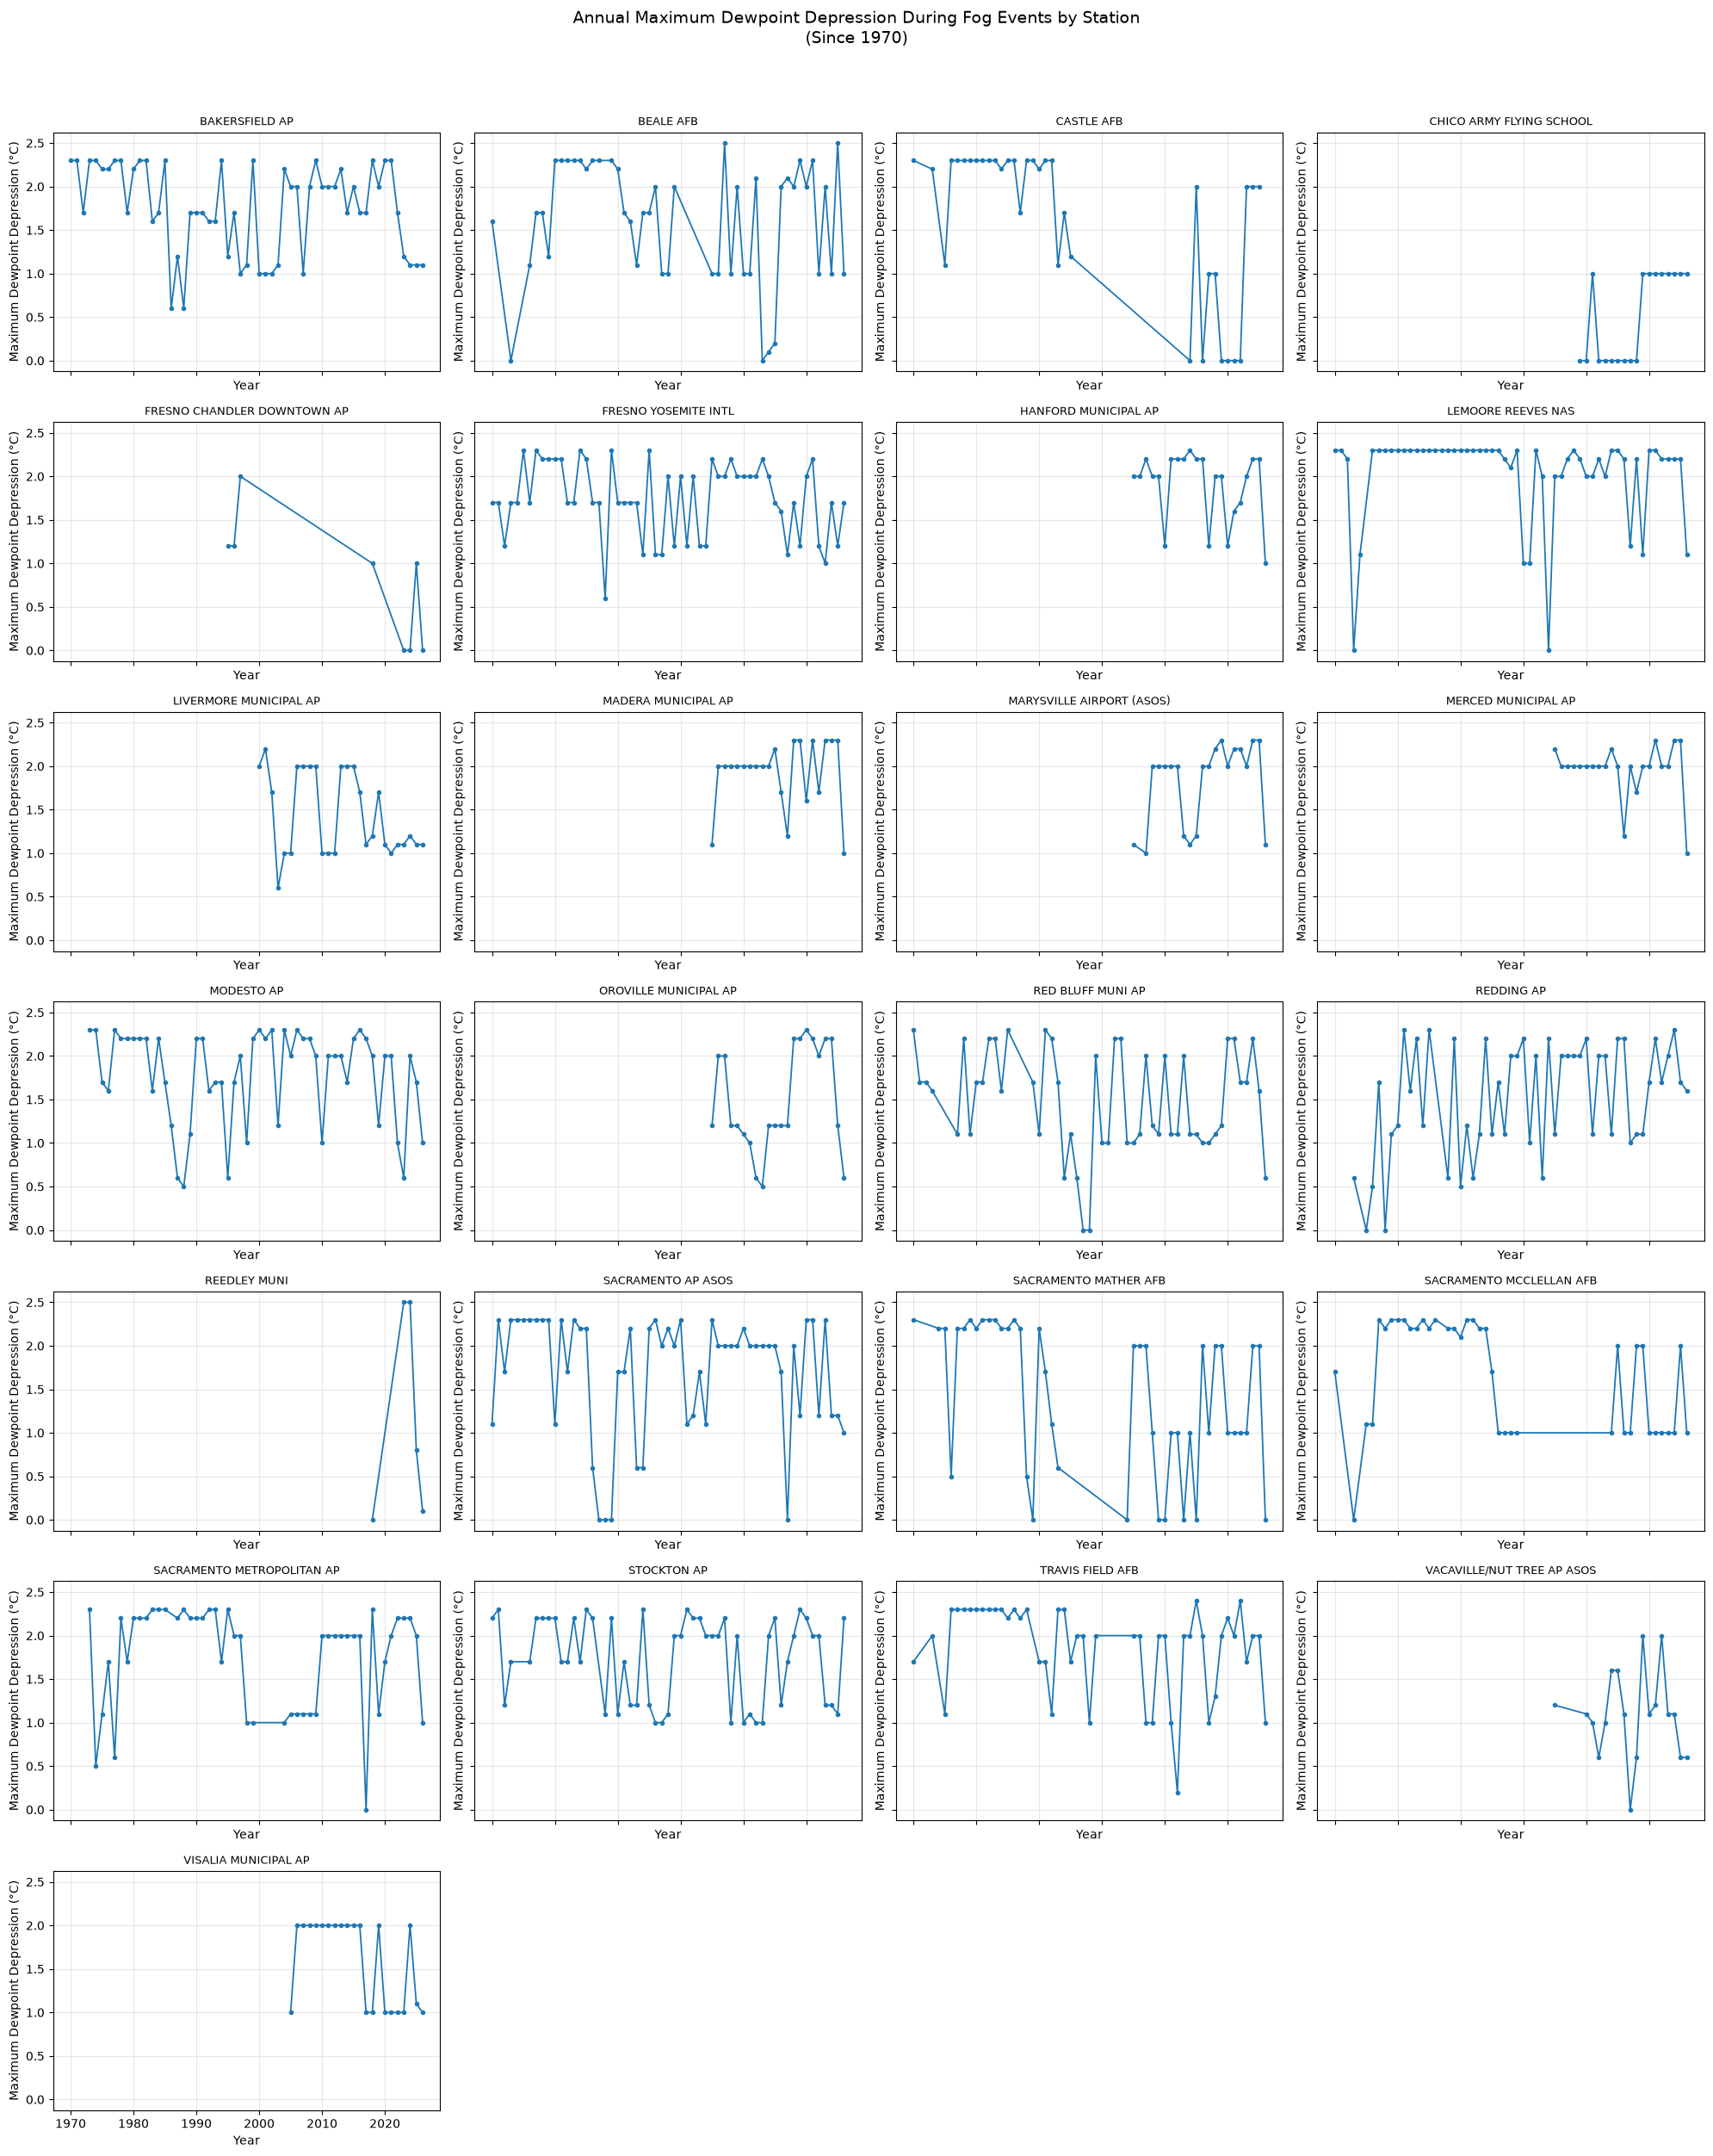

In [18]:
# Maximum dewpoint depression during fog events by station and year since 1970

fog_max_source = fog_event_dd.copy()
fog_max_source["DATE"] = pd.to_datetime(fog_max_source["DATE"], errors="coerce")

fog_max_source = fog_max_source[
    (fog_max_source["DATE"].dt.year >= 1970)
].dropna(
    subset=["STATION", "DATE", "HourlyDewpointDepression"]
).copy()

fog_max_source["year"] = fog_max_source["DATE"].dt.year

annual_max_dd = (
    fog_max_source
    .groupby(["STATION", "year"], as_index=False)["HourlyDewpointDepression"]
    .max()
    .sort_values(["STATION", "year"])
)

stations_max = sorted(annual_max_dd["STATION"].unique())

if not stations_max:
    print("No fog-event data found since 1970.")
else:
    ncols = 4
    nrows = int(np.ceil(len(stations_max) / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.5 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.asarray(axes).reshape(-1)

    for idx, station_name in enumerate(stations_max):
        ax = axes[idx]
        group = annual_max_dd[
            annual_max_dd["STATION"] == station_name
        ]

        ax.plot(
            group["year"],
            group["HourlyDewpointDepression"],
            marker="o",
            markersize=3,
            linewidth=1.3
        )
        ax.set_title(station_name, fontsize=9)
        ax.set_xlabel("Year")
        ax.set_ylabel("Maximum Dewpoint Depression (°C)")
        ax.grid(alpha=0.3)

    for ax in axes[len(stations_max):]:
        ax.axis("off")

    fig.suptitle(
        "Annual Maximum Dewpoint Depression During Fog Events by Station\n(Since 1970)",
        y=1.02,
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

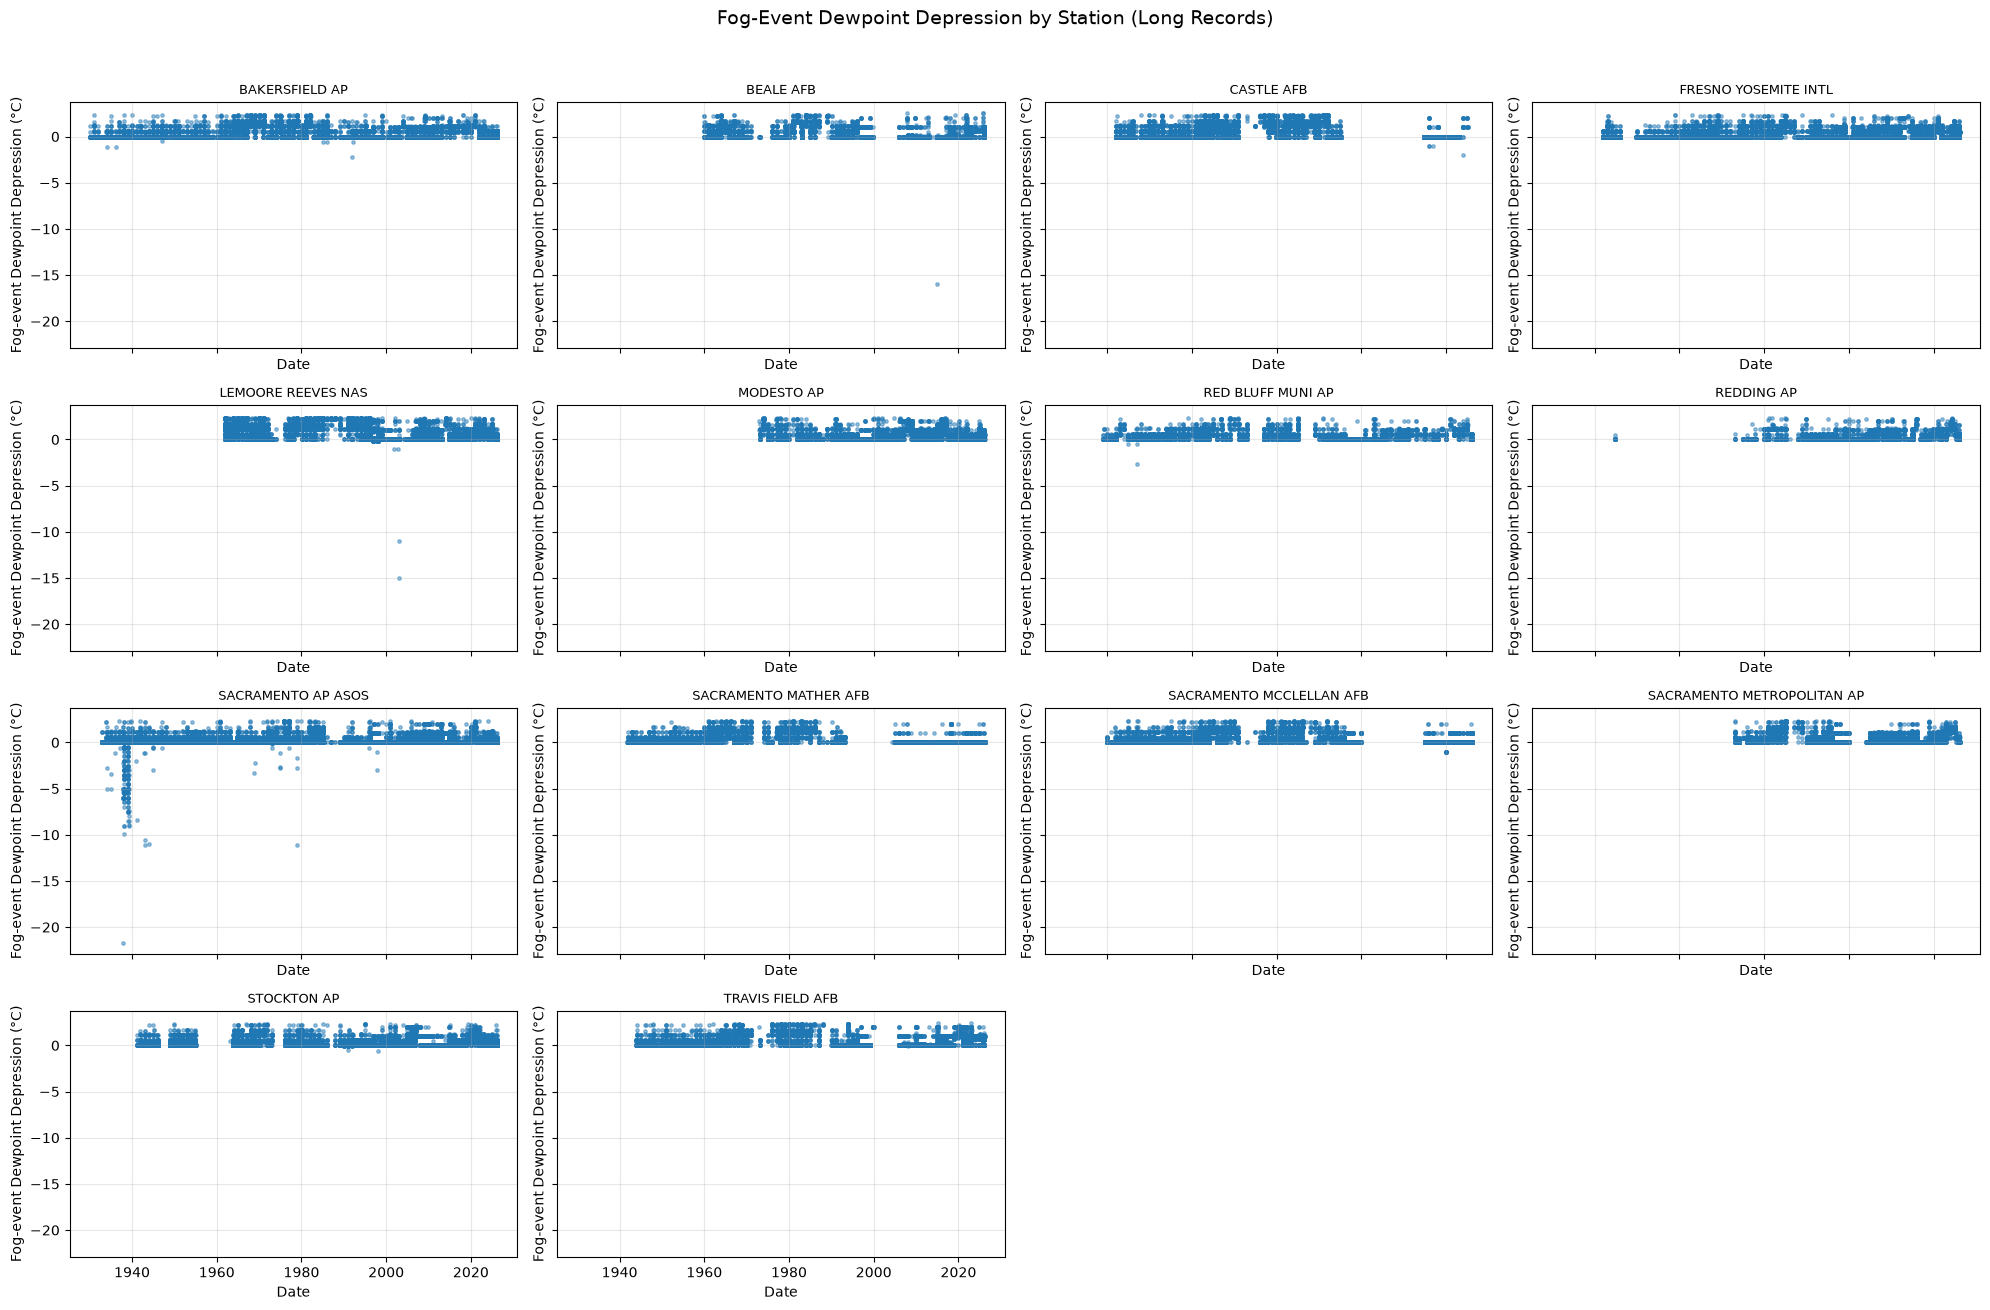

In [20]:
# Plot dewpoint depression for each fog event at long-record stations

# Use long-record station list if already created; otherwise build from CV_rows (>30 unique years)
if "eligible_stations_30" in globals():
    long_record_stations = set(eligible_stations_30)
else:
    year_counts = CV_rows.groupby("STATION")["year"].nunique()
    long_record_stations = set(year_counts[year_counts > 30].index)

fog_event_long = fog_event_dd[fog_event_dd["STATION"].isin(long_record_stations)].copy()
fog_event_long = fog_event_long.dropna(subset=["DATE", "HourlyDewpointDepression"])

stations_long = sorted(fog_event_long["STATION"].unique())
n_stations = len(stations_long)

if n_stations == 0:
    print("No long-record stations found in fog_event_dd.")
else:
    ncols = 4
    nrows = int(np.ceil(n_stations / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.2 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    for i, station_name in enumerate(stations_long):
        ax = axes[i]
        g = fog_event_long[fog_event_long["STATION"] == station_name].sort_values("DATE")

        ax.scatter(
            g["DATE"],
            g["HourlyDewpointDepression"],
            s=6,
            alpha=0.45
        )
        ax.set_title(station_name, fontsize=9)
        ax.set_xlabel("Date")
        ax.set_ylabel("Fog-event Dewpoint Depression (°C)")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Fog-Event Dewpoint Depression by Station (Long Records)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

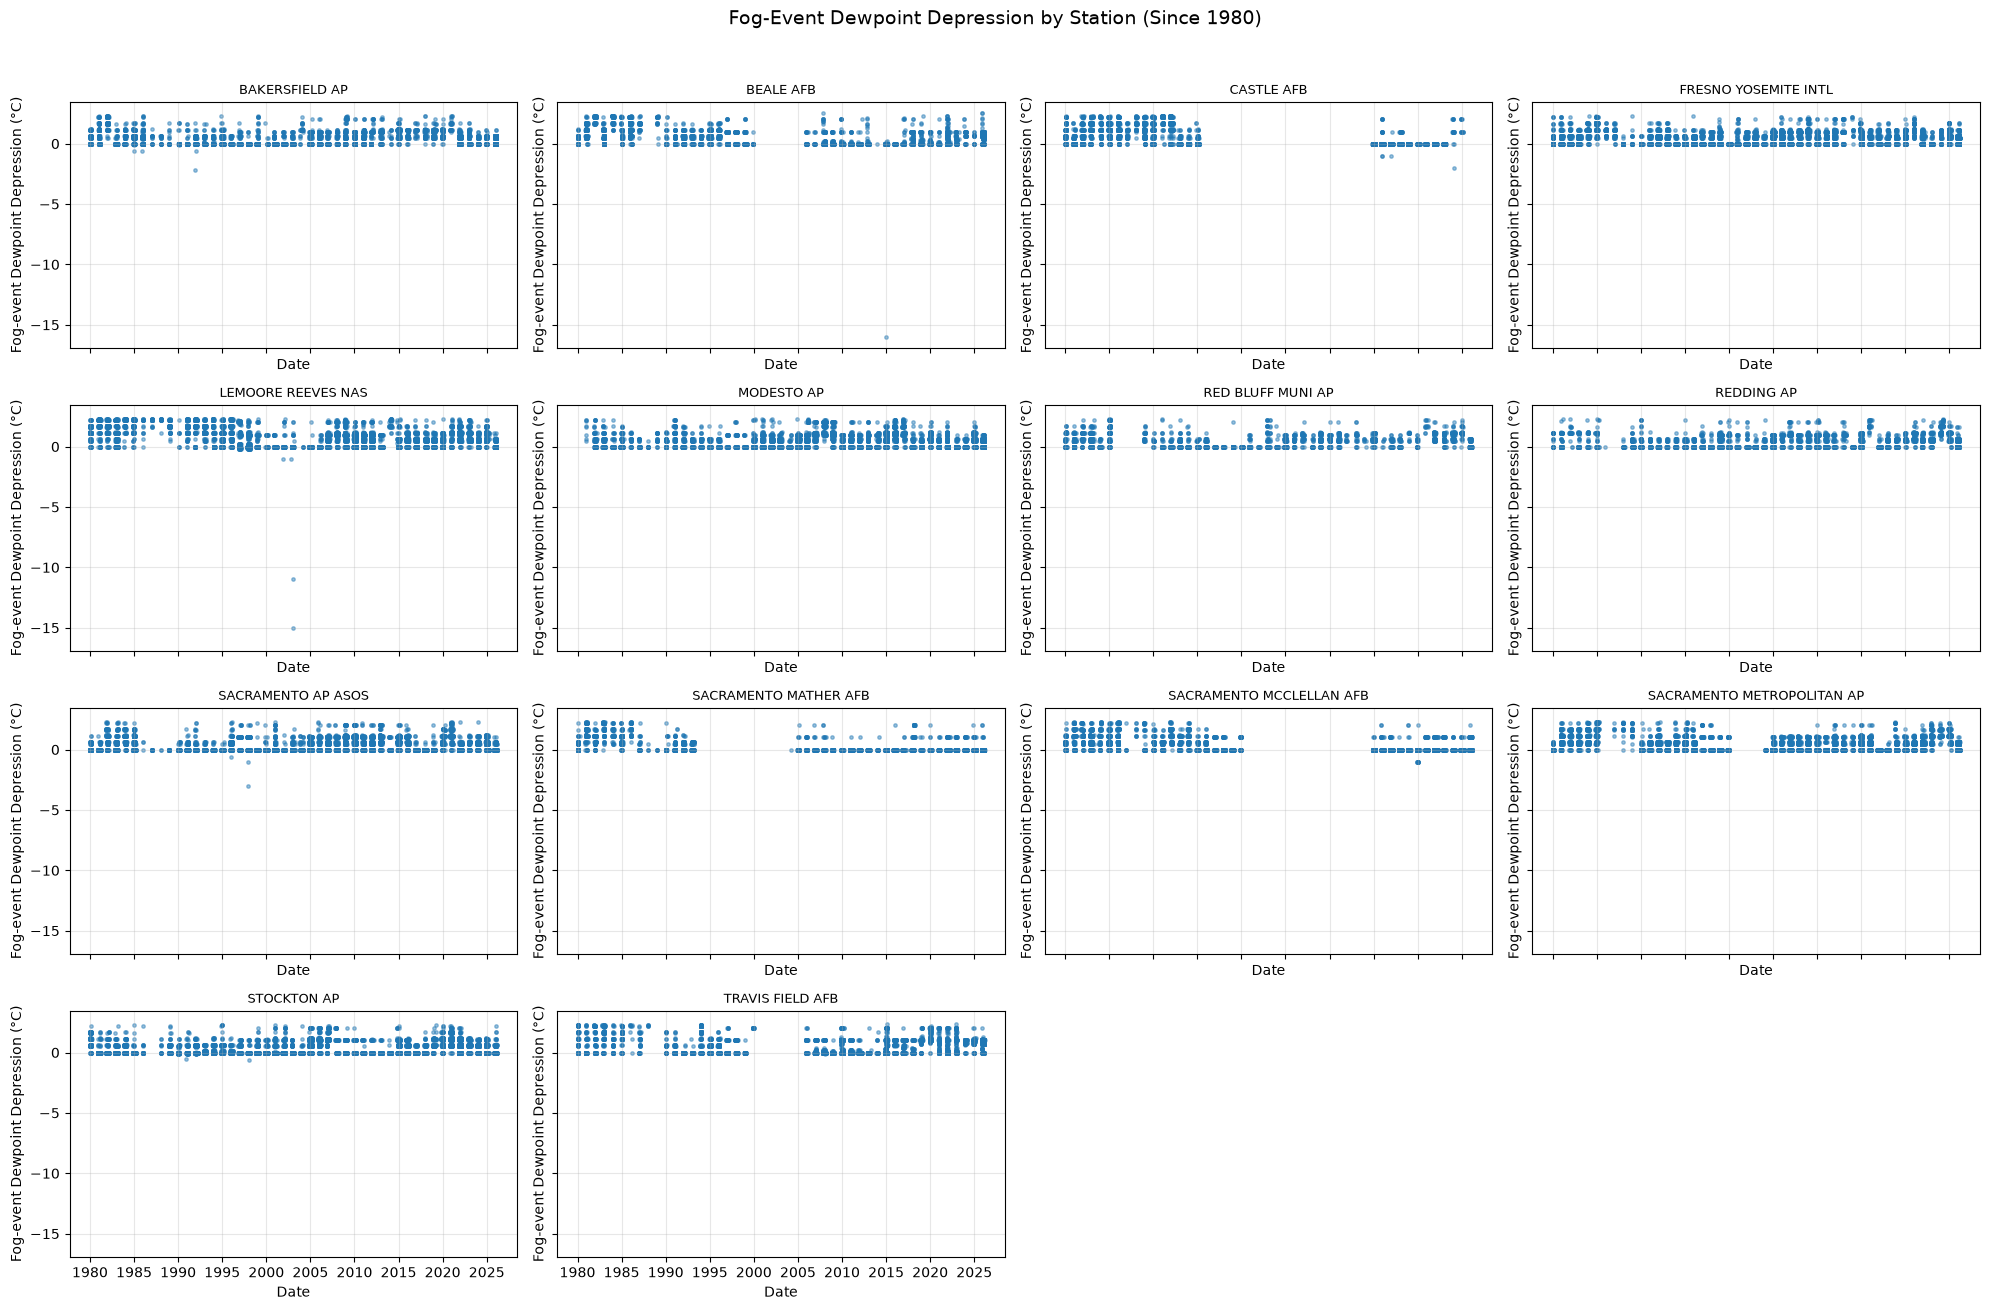

In [22]:
# Same fog-event dewpoint depression plot, but only for years since 1980

if "fog_event_long" in globals():
    fog_event_long_1980 = fog_event_long.copy()
else:
    fog_event_long_1980 = fog_event_dd[fog_event_dd["STATION"].isin(long_record_stations)].copy()

fog_event_long_1980["DATE"] = pd.to_datetime(fog_event_long_1980["DATE"], errors="coerce")
fog_event_long_1980 = fog_event_long_1980[
    fog_event_long_1980["DATE"].dt.year >= 1980
].dropna(subset=["DATE", "HourlyDewpointDepression"])

stations_long_1980 = sorted(fog_event_long_1980["STATION"].unique())
n_stations_1980 = len(stations_long_1980)

if n_stations_1980 == 0:
    print("No fog-event records since 1980 for long-record stations.")
else:
    ncols = 4
    nrows = int(np.ceil(n_stations_1980 / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.2 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    for i, station_name in enumerate(stations_long_1980):
        ax = axes[i]
        g = fog_event_long_1980[fog_event_long_1980["STATION"] == station_name].sort_values("DATE")

        ax.scatter(
            g["DATE"],
            g["HourlyDewpointDepression"],
            s=6,
            alpha=0.45
        )
        ax.set_title(station_name, fontsize=9)
        ax.set_xlabel("Date")
        ax.set_ylabel("Fog-event Dewpoint Depression (°C)")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Fog-Event Dewpoint Depression by Station (Since 1980)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

Rows before filter: 113768
Rows after filter: 113633


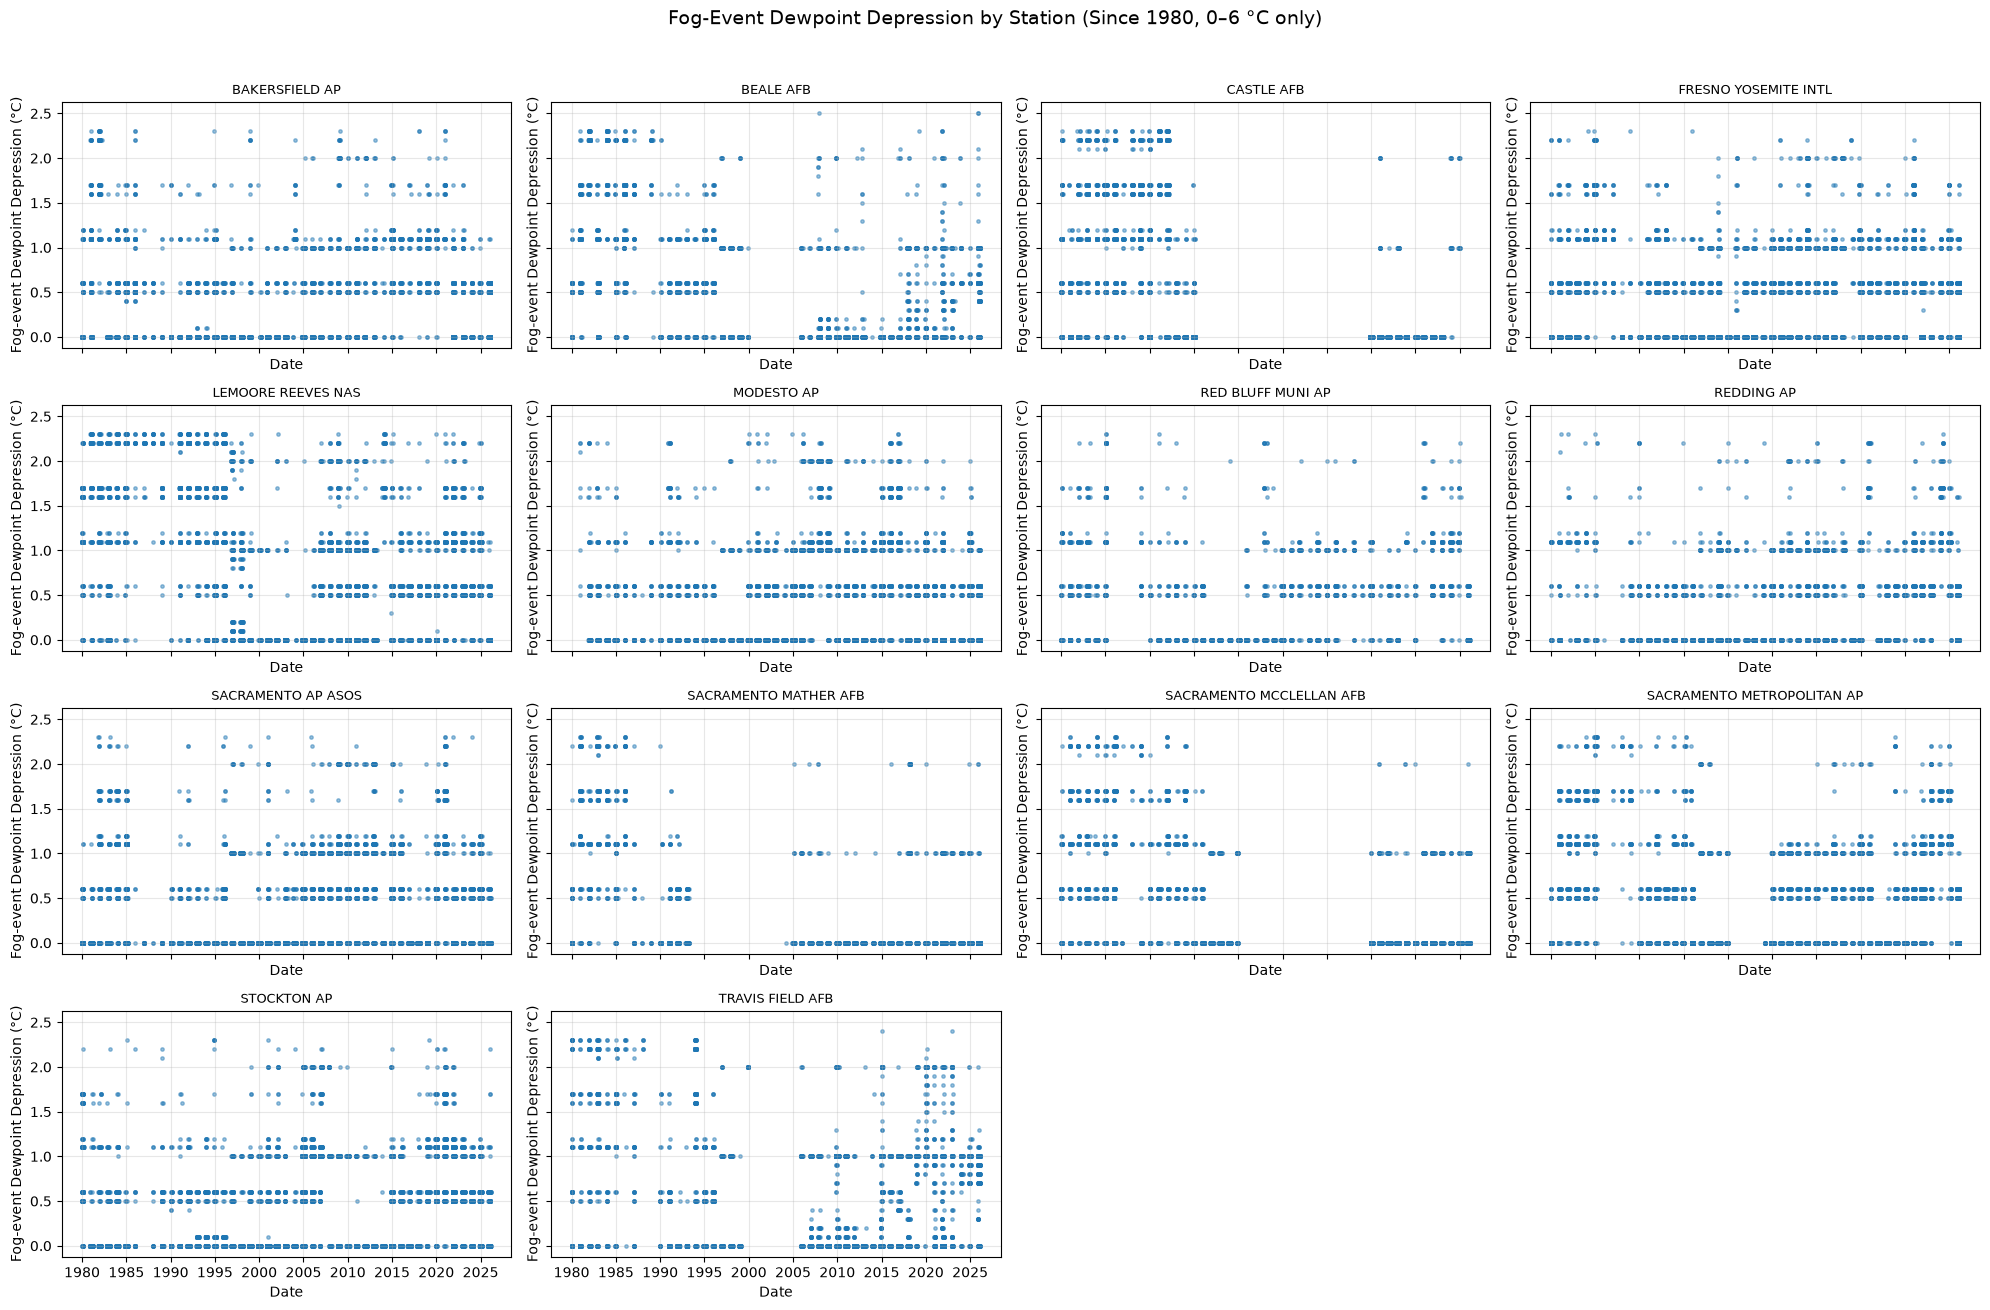

In [24]:
# Exclude unrealistic fog-event dewpoint depression values and re-plot (since 1980)
fog_event_long_1980_clean = fog_event_long_1980[
    (fog_event_long_1980["HourlyDewpointDepression"] >= 0) &
    (fog_event_long_1980["HourlyDewpointDepression"] <= 6)
].copy()

print("Rows before filter:", len(fog_event_long_1980))
print("Rows after filter:", len(fog_event_long_1980_clean))

stations_clean = sorted(fog_event_long_1980_clean["STATION"].unique())
n_stations_clean = len(stations_clean)

if n_stations_clean == 0:
    print("No records remain after filtering.")
else:
    ncols = 4
    nrows = int(np.ceil(n_stations_clean / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.2 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    for i, station_name in enumerate(stations_clean):
        ax = axes[i]
        g = fog_event_long_1980_clean[
            fog_event_long_1980_clean["STATION"] == station_name
        ].sort_values("DATE")

        ax.scatter(
            g["DATE"],
            g["HourlyDewpointDepression"],
            s=6,
            alpha=0.45
        )
        ax.set_title(station_name, fontsize=9)
        ax.set_xlabel("Date")
        ax.set_ylabel("Fog-event Dewpoint Depression (°C)")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        "Fog-Event Dewpoint Depression by Station (Since 1980, 0–6 °C only)",
        y=1.02,
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

In [25]:
# the allowed values for dewpoint depression during fog events (0.5, 1.0, 1.5, 2.0, 2.5, 3.0 °C)
allowed_values = np.arange(0.5, 3.01, 0.5)

fog_event_long_1980_clean["HourlyDewpointDepression"] = (
    fog_event_long_1980_clean["HourlyDewpointDepression"]
    .apply(lambda x: allowed_values[np.abs(allowed_values - x).argmin()])
)

fog_event_long_1980_clean["HourlyDewpointDepression"].value_counts().sort_index()

HourlyDewpointDepression
0.5    85384
1.0    20275
1.5     4575
2.0     2959
2.5      440
Name: count, dtype: int64

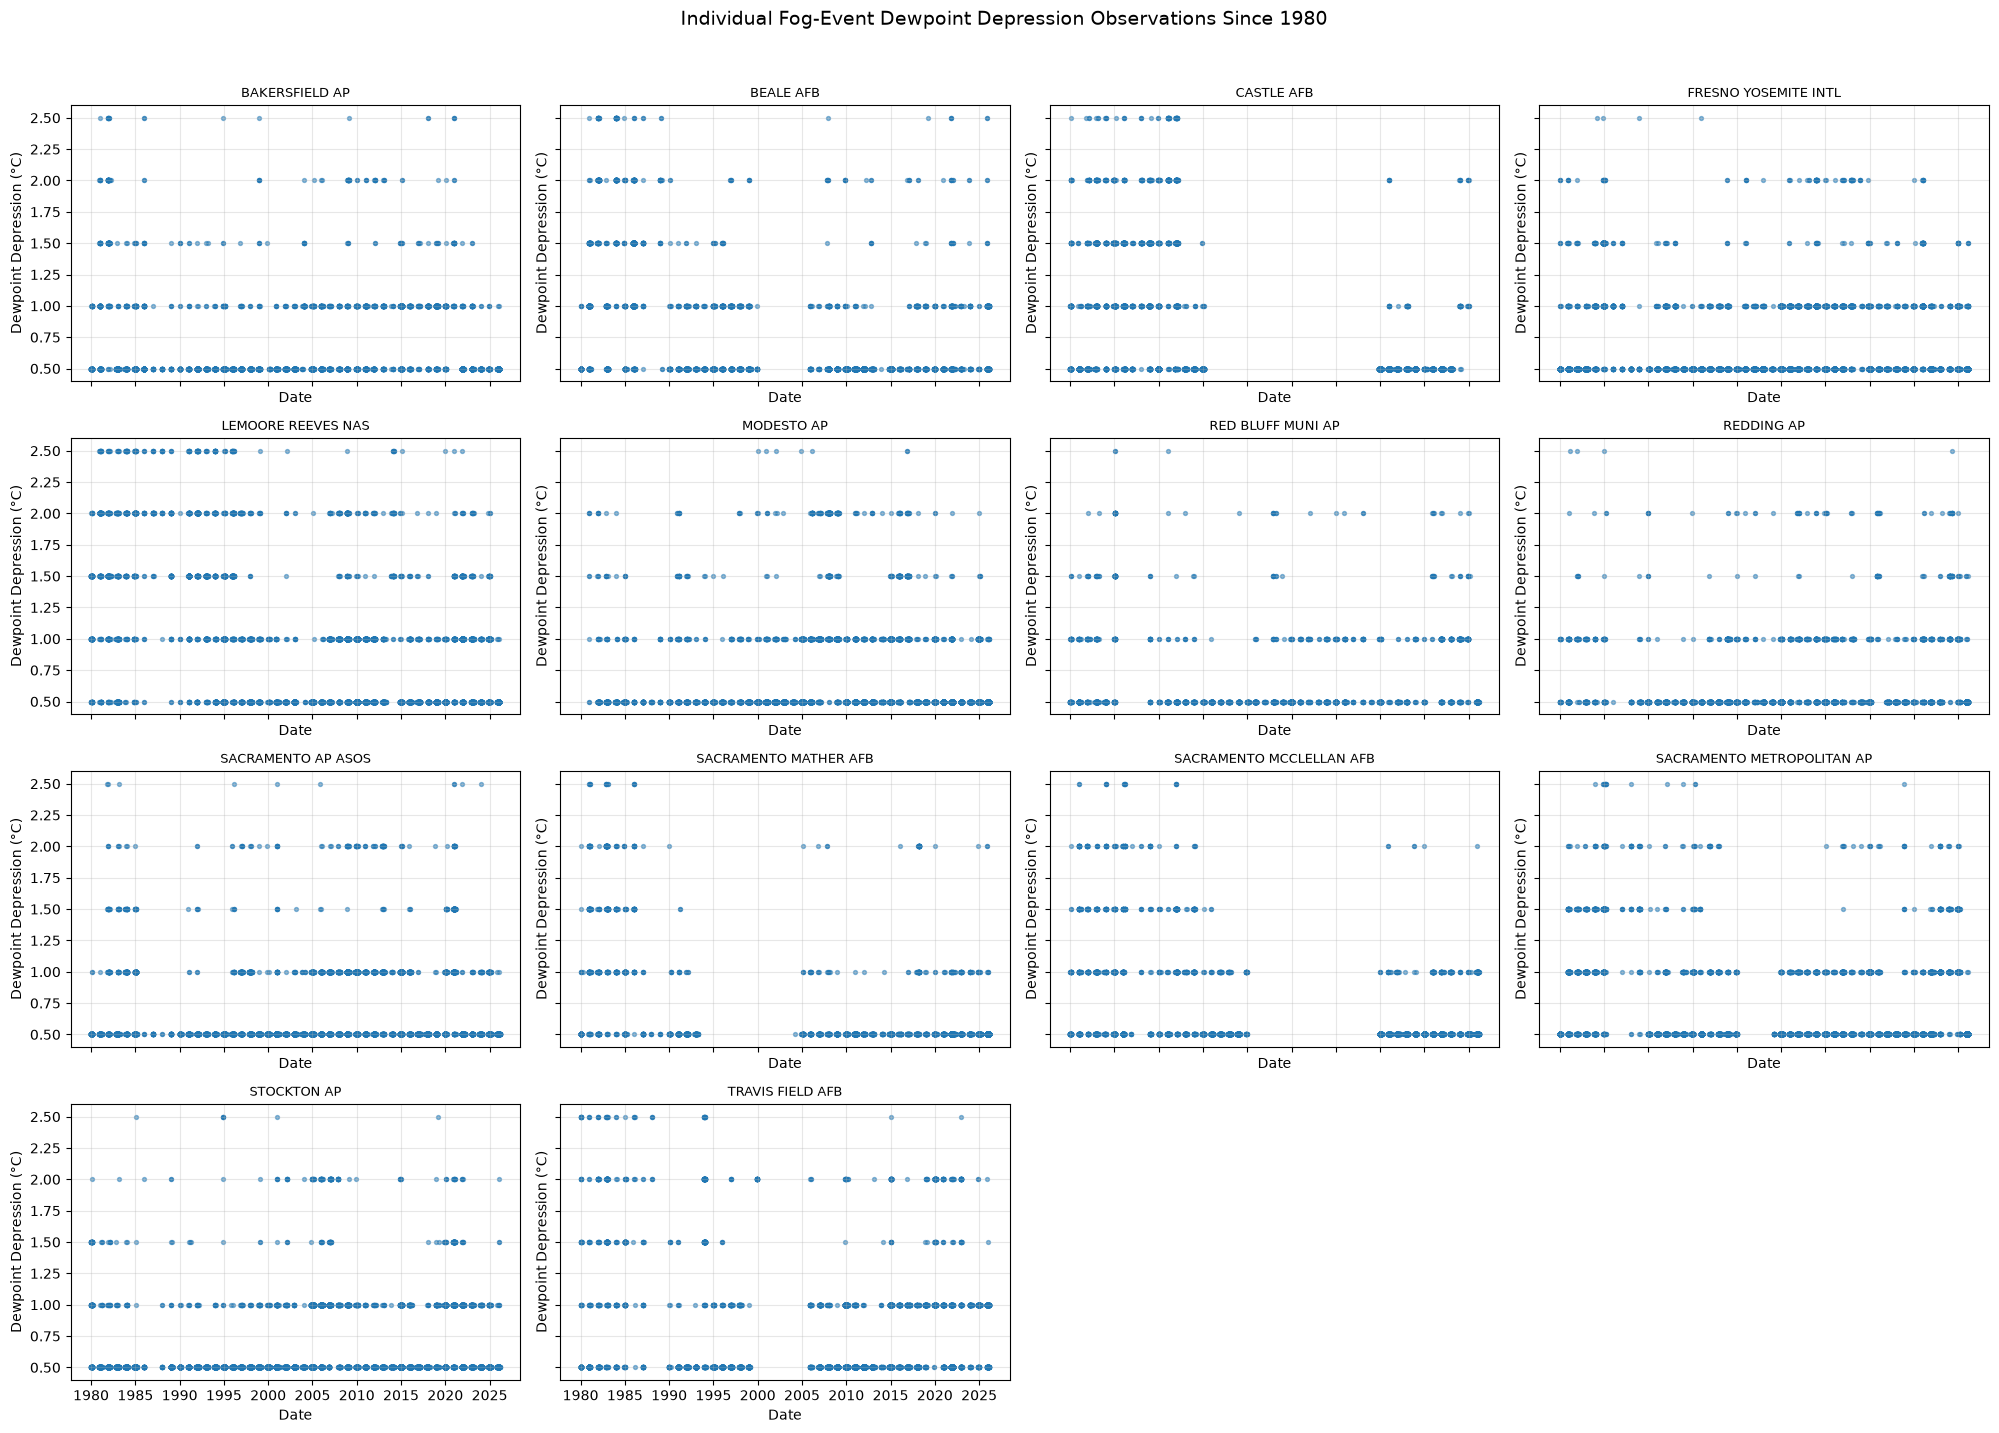

In [27]:
# Plot individual dewpoint-depression events over time for each station

plot_source = fog_event_long_1980_clean.copy()
plot_source["DATE"] = pd.to_datetime(plot_source["DATE"], errors="coerce")
plot_source = plot_source.dropna(
    subset=["STATION", "DATE", "HourlyDewpointDepression"]
)

stations_event_plot = sorted(plot_source["STATION"].unique())
ncols_event_plot = 4
nrows_event_plot = int(np.ceil(len(stations_event_plot) / ncols_event_plot))

fig, axes_event_plot = plt.subplots(
    nrows=nrows_event_plot,
    ncols=ncols_event_plot,
    figsize=(5 * ncols_event_plot, 3.5 * nrows_event_plot),
    sharex=True,
    sharey=True
)

axes_event_plot = np.asarray(axes_event_plot).reshape(-1)

for i, station_name in enumerate(stations_event_plot):
    ax = axes_event_plot[i]
    station_data = plot_source[
        plot_source["STATION"] == station_name
    ].sort_values("DATE")

    ax.scatter(
        station_data["DATE"],
        station_data["HourlyDewpointDepression"],
        s=8,
        alpha=0.5
    )

    ax.set_title(station_name, fontsize=9)
    ax.set_xlabel("Date")
    ax.set_ylabel("Dewpoint Depression (°C)")
    ax.grid(alpha=0.3)

for ax in axes_event_plot[len(stations_event_plot):]:
    ax.axis("off")

fig.suptitle(
    "Individual Fog-Event Dewpoint Depression Observations Since 1980",
    y=1.02,
    fontsize=14
)

plt.tight_layout()
plt.show()

In [28]:
# Compute HourlyDewpointDepression for CV_filtered_rows and examine relationship
# between low dewpoint depression (<1, <2) and fog occurrence (HourlyVisibility < 1) by station

analysis_df = CV_filtered_rows.dropna(
    subset=["HourlyDryBulbTemperature", "HourlyDewPointTemperature", "HourlyVisibility"]
).copy()

analysis_df["HourlyDewpointDepression"] = (
    analysis_df["HourlyDryBulbTemperature"] - analysis_df["HourlyDewPointTemperature"]
).clip(lower=0)

analysis_df["dd_lt1"] = (analysis_df["HourlyDewpointDepression"] < 1).astype(int)
analysis_df["dd_lt2"] = (analysis_df["HourlyDewpointDepression"] < 2).astype(int)
analysis_df["is_fog"] = (analysis_df["HourlyVisibility"] < 1).astype(int)

station_results = []

for station_name, g in analysis_df.groupby("STATION"):
    n_rows = len(g)
    n_dd_lt1 = g["dd_lt1"].sum()
    n_dd_lt2 = g["dd_lt2"].sum()

    # Point-biserial correlation (Pearson corr between binary and binary/continuous works fine)
    if g["dd_lt1"].nunique() > 1 and g["is_fog"].nunique() > 1:
        corr_lt1 = g["dd_lt1"].corr(g["is_fog"])
    else:
        corr_lt1 = np.nan

    if g["dd_lt2"].nunique() > 1 and g["is_fog"].nunique() > 1:
        corr_lt2 = g["dd_lt2"].corr(g["is_fog"])
    else:
        corr_lt2 = np.nan

    station_results.append({
        "STATION": station_name,
        "n_rows": n_rows,
        "n_dd_lt1": n_dd_lt1,
        "n_dd_lt2": n_dd_lt2,
        "n_fog": g["is_fog"].sum(),
        "corr_dd_lt1_vs_fog": corr_lt1,
        "corr_dd_lt2_vs_fog": corr_lt2
    })

station_dd_fog_corr = pd.DataFrame(station_results).sort_values(
    "corr_dd_lt2_vs_fog", ascending=False
)

pd.set_option("display.max_rows", None)
print(station_dd_fog_corr)

                        STATION  n_rows  n_dd_lt1  n_dd_lt2  n_fog  \
10           LEMOORE REEVES NAS  212433     21629     54053  17010   
28           VERNALIS NAVAL AUX     898        68       159     30   
0                BAKERSFIELD AP  345808     27750     75341  14126   
9          HANFORD MUNICIPAL AP  113610     28308     59452  15024   
6          FRESNO YOSEMITE INTL  307221     46661    110171  20363   
8                    HAMMER AAF    3132       628      1403    271   
15          MERCED MUNICIPAL AP  105703     16840     45257   8324   
24   SACRAMENTO METROPOLITAN AP  161170     26334     61551  10237   
5   FRESNO CHANDLER DOWNTOWN AP   78719     18882     32340   5387   
25                  STOCKTON AP  258254     48910    107203  17603   
2                    CASTLE AFB  208386     45810     79195  14798   
16                   MODESTO AP  170101     27747     64077  10424   
13          MADERA MUNICIPAL AP  103730     13815     41954   6526   
23     SACRAMENTO MC

                       STATION  n_years  slope_C_per_year  slope_C_per_decade  \
7                   REDDING AP       28         -0.006312           -0.063123   
4           LEMOORE REEVES NAS       41         -0.005362           -0.053622   
13            TRAVIS FIELD AFB       33          0.000246            0.002458   
3         FRESNO YOSEMITE INTL       34          0.000661            0.006606   
12                 STOCKTON AP       29          0.000707            0.007068   
6            RED BLUFF MUNI AP       22          0.001399            0.013994   
5                   MODESTO AP       35          0.001885            0.018849   
11  SACRAMENTO METROPOLITAN AP       31          0.003062            0.030615   
0               BAKERSFIELD AP       32          0.003652            0.036516   
1                    BEALE AFB       27          0.006135            0.061346   
9        SACRAMENTO MATHER AFB       18          0.007527            0.075267   
10    SACRAMENTO MCCLELLAN A

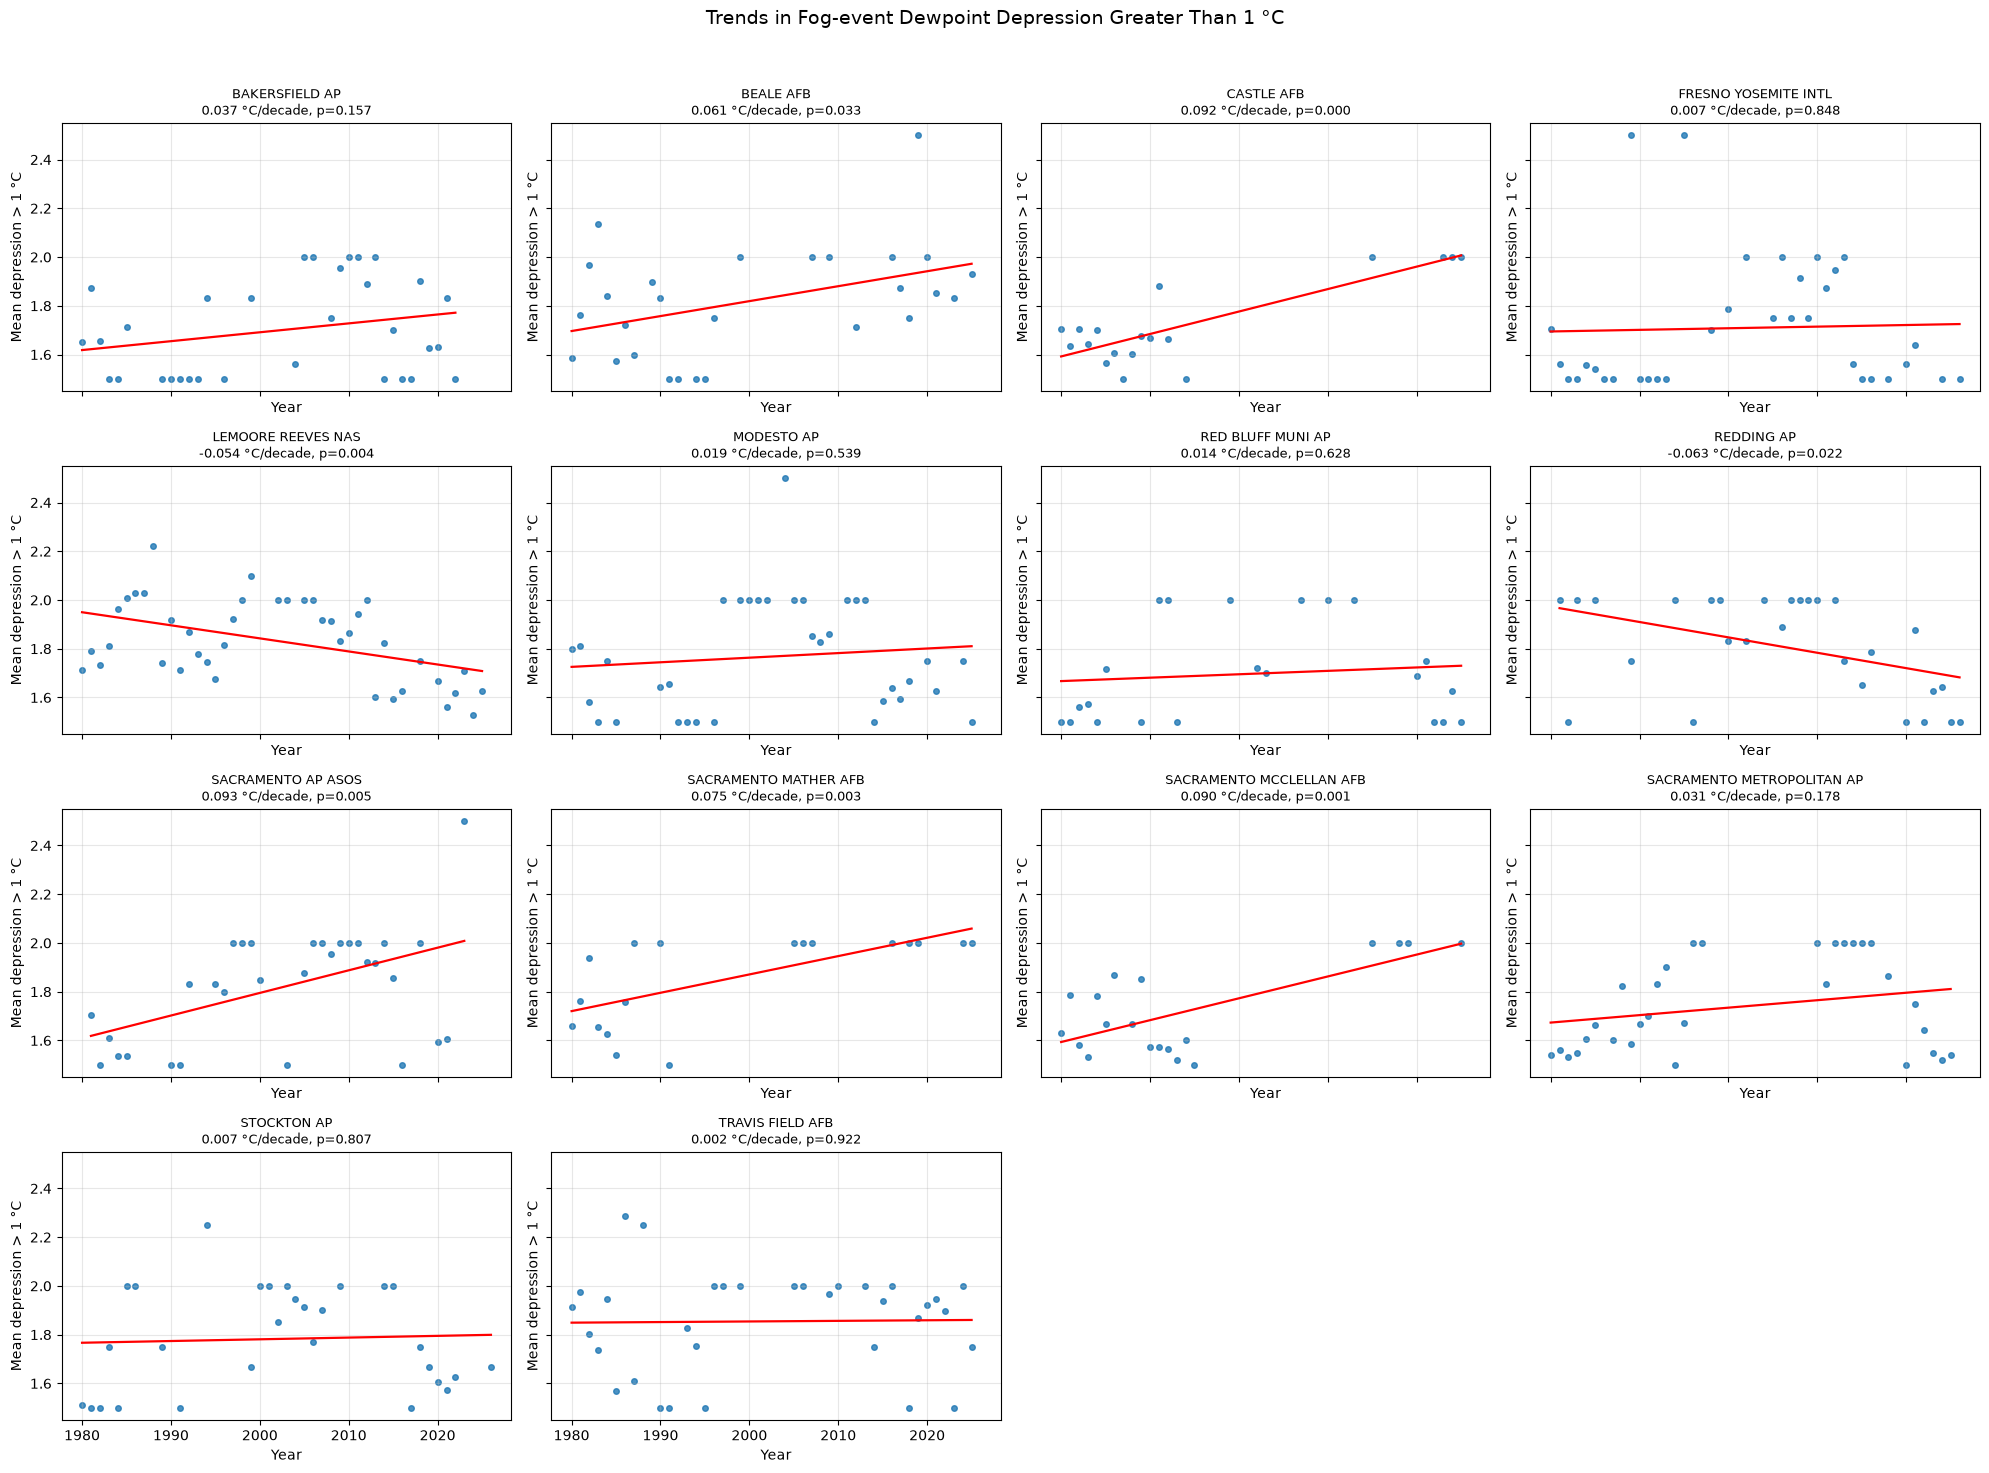

In [31]:
# Trends in fog-event dewpoint depression > 1 °C since 1980

trend_source = fog_event_long_1980_clean.copy()
trend_source["DATE"] = pd.to_datetime(trend_source["DATE"], errors="coerce")
trend_source["year"] = trend_source["DATE"].dt.year

trend_source = trend_source[
    (trend_source["HourlyDewpointDepression"] > 1) &
    (trend_source["year"] >= 1980)
].dropna(subset=["STATION", "year", "HourlyDewpointDepression"])

# Annual mean depression above 1 °C by station
annual_dd_gt1 = (
    trend_source
    .groupby(["STATION", "year"], as_index=False)
    ["HourlyDewpointDepression"]
    .mean()
)

trend_rows = []

for station_name, group in annual_dd_gt1.groupby("STATION"):
    group = group.sort_values("year")

    if group["year"].nunique() < 2:
        continue

    fit = stats.linregress(
        group["year"],
        group["HourlyDewpointDepression"]
    )

    trend_rows.append({
        "STATION": station_name,
        "n_years": group["year"].nunique(),
        "slope_C_per_year": fit.slope,
        "slope_C_per_decade": fit.slope * 10,
        "p_value": fit.pvalue,
        "r_squared": fit.rvalue ** 2,
        "significant_p05": fit.pvalue < 0.05
    })

trends_dd_gt1 = (
    pd.DataFrame(trend_rows)
    .sort_values("slope_C_per_decade")
)

print(trends_dd_gt1)

# Plot annual means and linear trends
stations_gt1 = sorted(annual_dd_gt1["STATION"].unique())
ncols = 4
nrows = int(np.ceil(len(stations_gt1) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.6 * nrows),
    sharex=True,
    sharey=True
)
axes = np.asarray(axes).reshape(-1)

for i, station_name in enumerate(stations_gt1):
    ax = axes[i]
    group = annual_dd_gt1[
        annual_dd_gt1["STATION"] == station_name
    ].sort_values("year")

    x = group["year"].to_numpy()
    y = group["HourlyDewpointDepression"].to_numpy()
    fit = stats.linregress(x, y)

    ax.scatter(x, y, s=16, alpha=0.8)
    ax.plot(
        x,
        fit.intercept + fit.slope * x,
        color="red",
        linewidth=1.6
    )

    ax.set_title(
        f"{station_name}\n"
        f"{fit.slope * 10:.3f} °C/decade, p={fit.pvalue:.3f}",
        fontsize=9
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean depression > 1 °C")
    ax.grid(alpha=0.3)

for ax in axes[len(stations_gt1):]:
    ax.axis("off")

fig.suptitle(
    "Trends in Fog-event Dewpoint Depression Greater Than 1 °C",
    y=1.02,
    fontsize=14
)
plt.tight_layout()
plt.show()

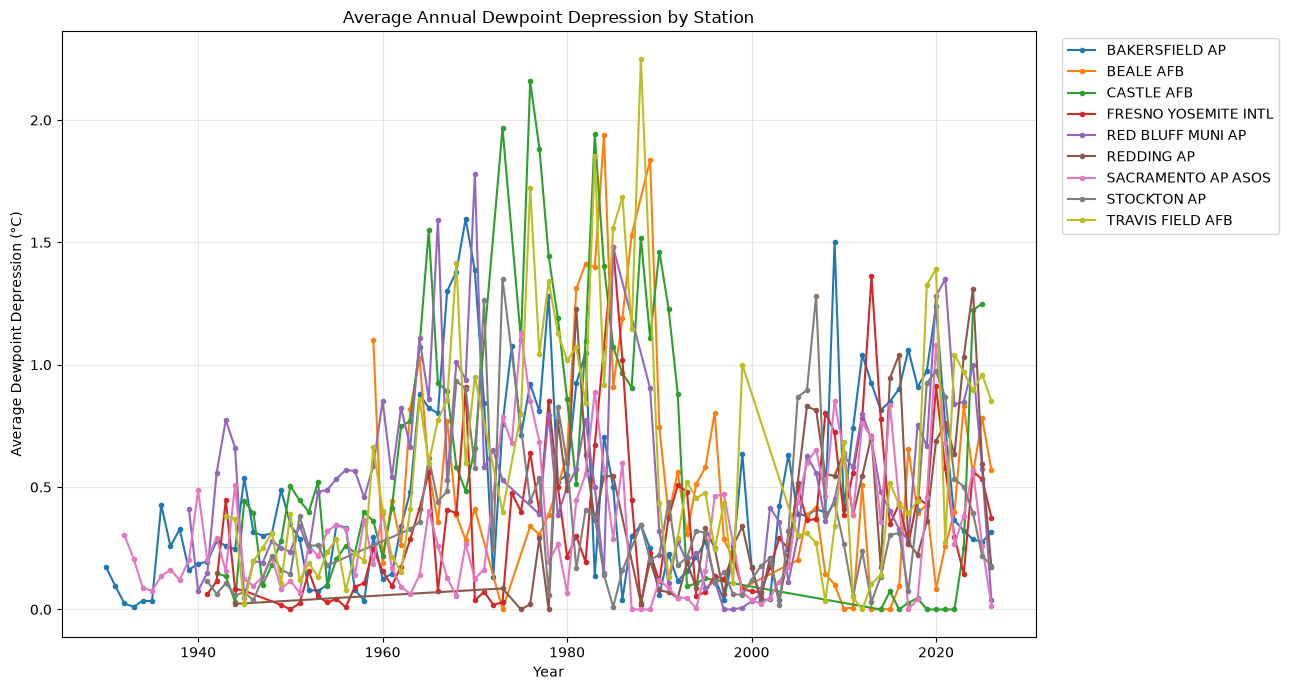

In [32]:
selected_stations = [
    "REDDING AP",
    "RED BLUFF MUNI AP",
    "BEALE AFB",
    "SACRAMENTO AP ASOS",
    "STOCKTON AP",
    "TRAVIS FIELD AFB",
    "CASTLE AFB",
    "FRESNO YOSEMITE INTL",
    "BAKERSFIELD AP",
]

plot_data = annual_station[
    annual_station["STATION"].isin(selected_stations)
].sort_values(["STATION", "year"])

fig, ax = plt.subplots(figsize=(13, 7))

for station_name, group in plot_data.groupby("STATION"):
    ax.plot(
        group["year"],
        group["HourlyDewpointDepression"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=station_name
    )

ax.set_title("Average Annual Dewpoint Depression by Station")
ax.set_xlabel("Year")
ax.set_ylabel("Average Dewpoint Depression (°C)")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

                       STATION  slope_per_year  slope_per_decade  \
4           LEMOORE REEVES NAS       -0.024556         -0.245556   
1                    BEALE AFB       -0.013873         -0.138734   
10    SACRAMENTO MCCLELLAN AFB       -0.010891         -0.108912   
9        SACRAMENTO MATHER AFB       -0.010846         -0.108455   
13            TRAVIS FIELD AFB       -0.008979         -0.089795   
2                   CASTLE AFB       -0.008697         -0.086971   
11  SACRAMENTO METROPOLITAN AP       -0.008113         -0.081127   
3         FRESNO YOSEMITE INTL       -0.001173         -0.011726   
5                   MODESTO AP       -0.000224         -0.002240   
8           SACRAMENTO AP ASOS        0.001509          0.015091   
6            RED BLUFF MUNI AP        0.001678          0.016780   
7                   REDDING AP        0.001866          0.018659   
12                 STOCKTON AP        0.002331          0.023307   
0               BAKERSFIELD AP        0.002642  

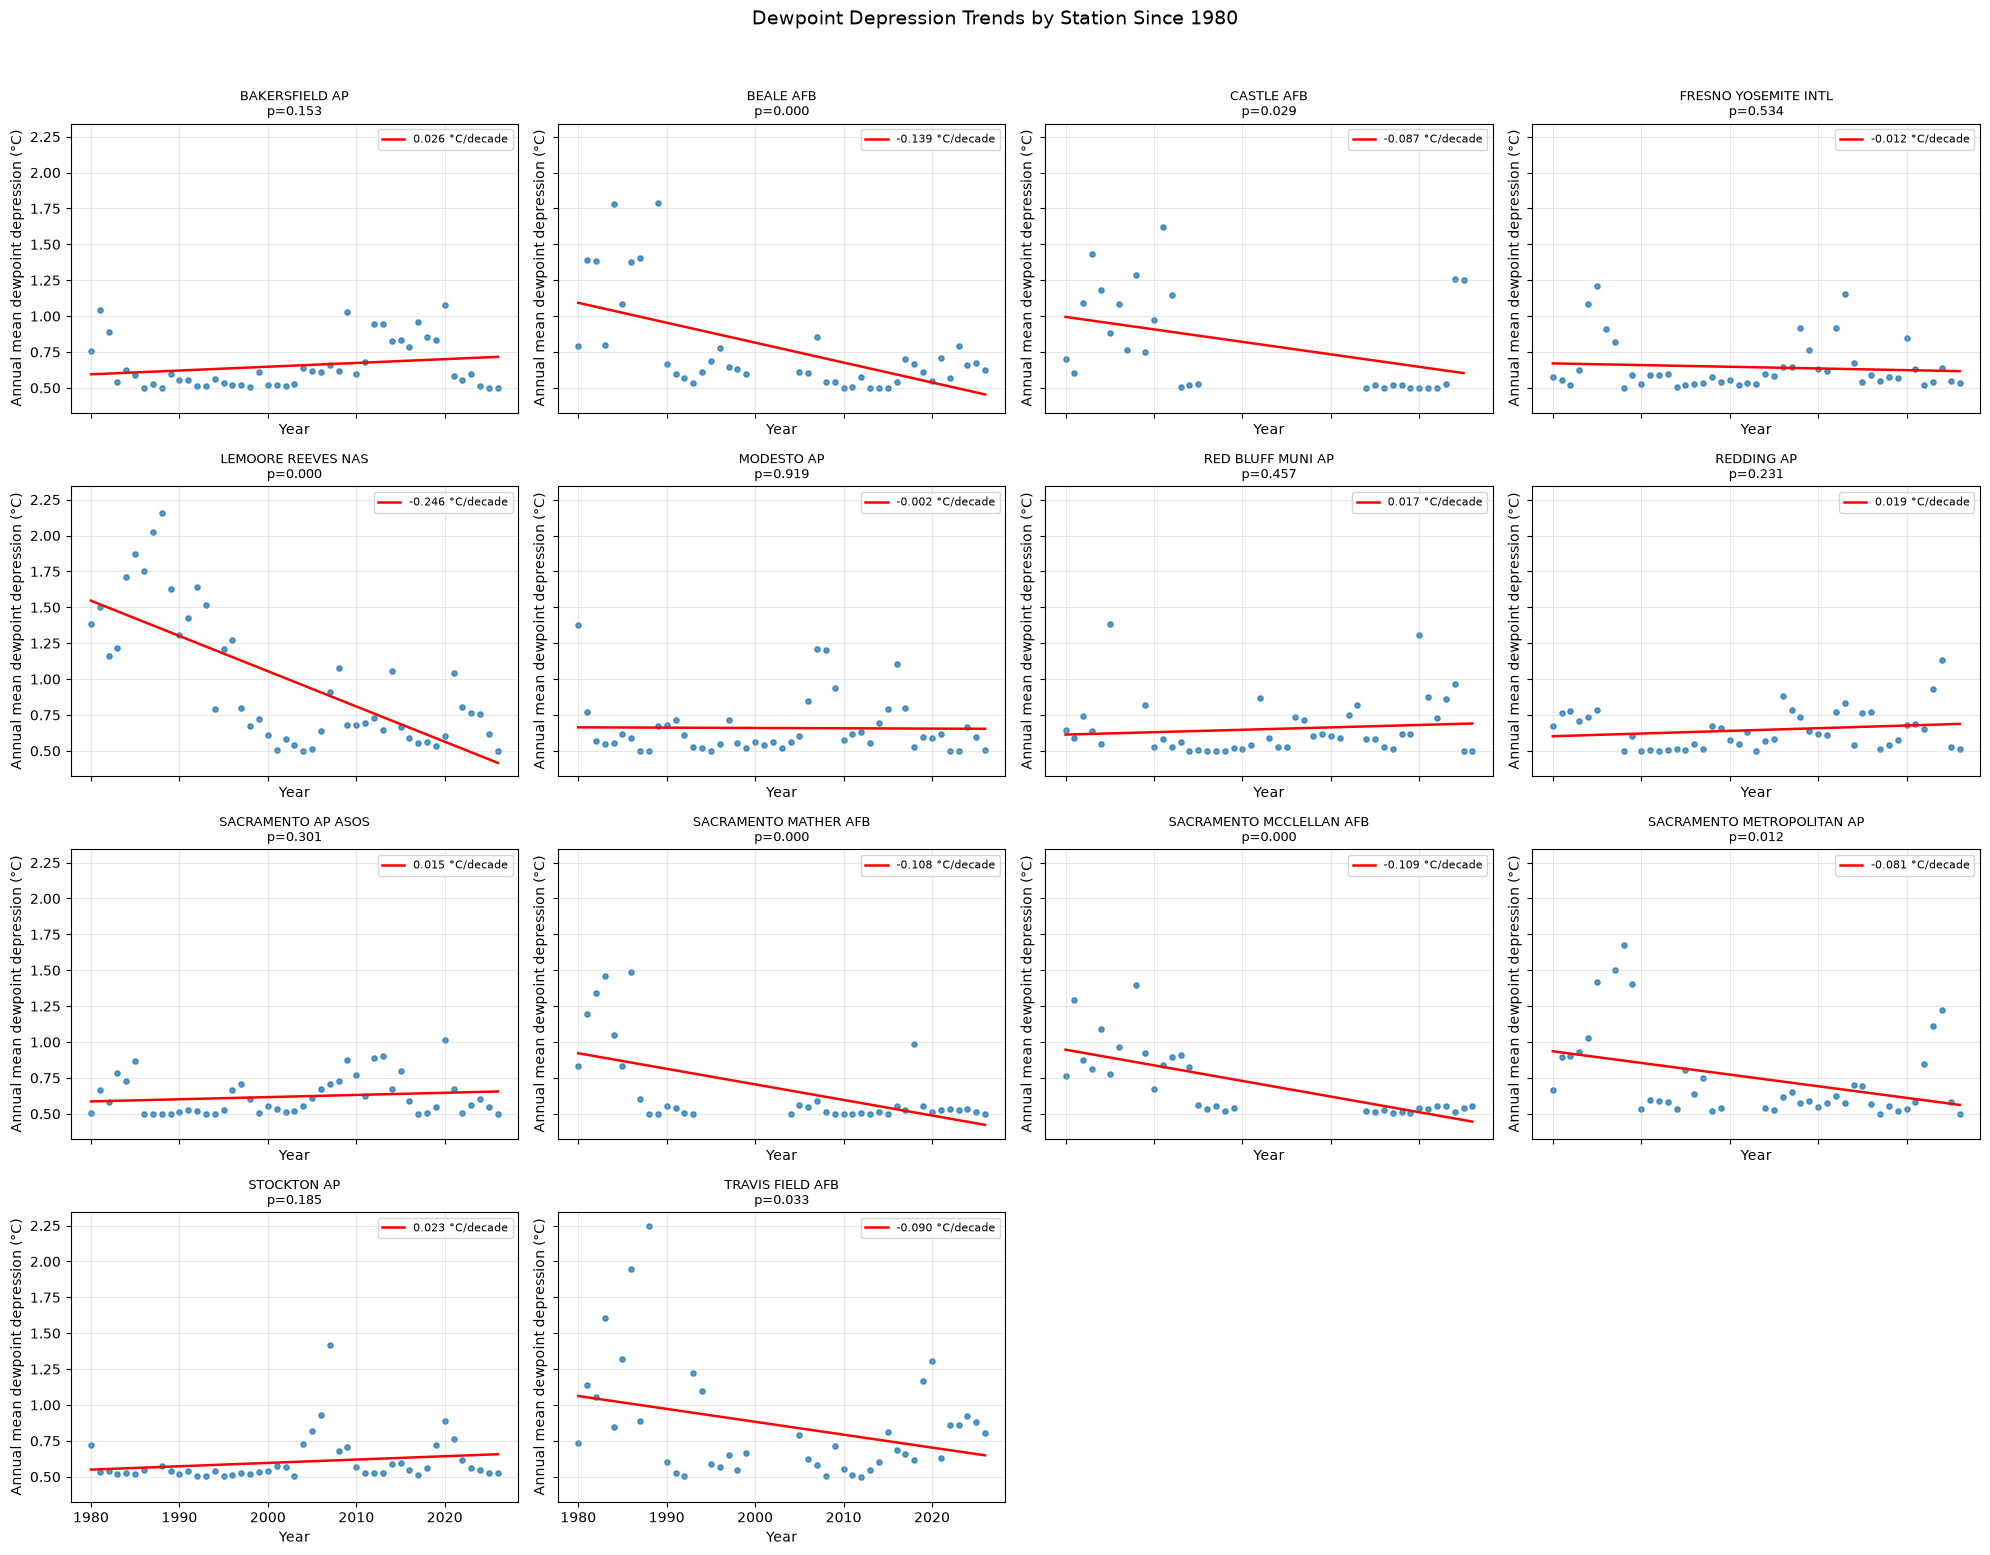

In [34]:
# Fit linear trends to annual mean dewpoint depression for each station

trend_source = fog_event_long_1980_clean.copy()
trend_source["year"] = trend_source["DATE"].dt.year

station_year_dd = (
    trend_source
    .groupby(["STATION", "year"], as_index=False)["HourlyDewpointDepression"]
    .mean()
)

trend_results = []

for station_name, group in station_year_dd.groupby("STATION"):
    group = group.sort_values("year")

    if group["year"].nunique() < 2:
        continue

    fit = stats.linregress(
        group["year"],
        group["HourlyDewpointDepression"]
    )

    trend_results.append({
        "STATION": station_name,
        "slope_per_year": fit.slope,
        "slope_per_decade": fit.slope * 10,
        "p_value": fit.pvalue,
        "r_squared": fit.rvalue ** 2,
        "n_years": group["year"].nunique()
    })

trend_results = (
    pd.DataFrame(trend_results)
    .sort_values("slope_per_year")
)

print(trend_results)

# Plot station-level trends
stations_trend = sorted(station_year_dd["STATION"].unique())
ncols = 4
nrows = int(np.ceil(len(stations_trend) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.8 * nrows),
    sharex=True,
    sharey=True
)

axes = np.asarray(axes).reshape(-1)

for i, station_name in enumerate(stations_trend):
    ax = axes[i]
    group = station_year_dd[
        station_year_dd["STATION"] == station_name
    ].sort_values("year")

    x = group["year"].to_numpy()
    y = group["HourlyDewpointDepression"].to_numpy()

    fit = stats.linregress(x, y)
    x_line = np.array([x.min(), x.max()])
    y_line = fit.intercept + fit.slope * x_line

    ax.scatter(x, y, s=14, alpha=0.75)
    ax.plot(
        x_line,
        y_line,
        color="red",
        linewidth=1.8,
        label=f"{fit.slope * 10:.3f} °C/decade"
    )

    ax.set_title(
        f"{station_name}\np={fit.pvalue:.3f}",
        fontsize=9
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual mean dewpoint depression (°C)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(stations_trend):]:
    ax.axis("off")

fig.suptitle(
    "Dewpoint Depression Trends by Station Since 1980",
    y=1.02,
    fontsize=14
)

plt.tight_layout()
plt.show()

In [35]:
# Trends in individual fog-event-hour dewpoint depression since 1980

selected_stations = [
    "BAKERSFIELD AP",
    "FRESNO YOSEMITE INTL",
    "RED BLUFF MUNI AP",
    "SACRAMENTO AP ASOS",
    "STOCKTON AP",
    "TRAVIS FIELD AFB",
]

# Prepare data for hourly dewpoint depression trends
fog_hourly_trends_source = fog_event_dd.copy()
fog_hourly_trends_source["DATE"] = pd.to_datetime(
    fog_hourly_trends_source["DATE"], errors="coerce"
)

fog_hourly_trends_source = fog_hourly_trends_source[
    fog_hourly_trends_source["STATION"].isin(selected_stations)
    & (fog_hourly_trends_source["DATE"].dt.year >= 1980)
].dropna(subset=["DATE", "HourlyDewpointDepression"]).copy()

fog_hourly_trends_source["year"] = (
    fog_hourly_trends_source["DATE"].dt.year
)

hourly_trend_rows = []

for station_name, group in fog_hourly_trends_source.groupby("STATION"):
    if group["year"].nunique() < 2:
        continue

    fit = stats.linregress(
        group["year"],
        group["HourlyDewpointDepression"]
    )

    hourly_trend_rows.append({
        "STATION": station_name,
        "n_fog_event_hours": len(group),
        "n_years": group["year"].nunique(),
        "slope_C_per_year": fit.slope,
        "slope_C_per_decade": fit.slope * 10,
        "p_value": fit.pvalue,
        "r_squared": fit.rvalue ** 2,
        "significant_p05": fit.pvalue < 0.05
    })

fog_hourly_trends = (
    pd.DataFrame(hourly_trend_rows)
    .set_index("STATION")
    .reindex(selected_stations)
)

print(fog_hourly_trends)

                      n_fog_event_hours  n_years  slope_C_per_year  \
STATION                                                              
BAKERSFIELD AP                     7059       47          0.003112   
FRESNO YOSEMITE INTL              11673       47          0.001978   
RED BLUFF MUNI AP                  3483       44         -0.000531   
SACRAMENTO AP ASOS                10914       47          0.002508   
STOCKTON AP                       12314       46          0.008925   
TRAVIS FIELD AFB                   9627       41         -0.004082   

                      slope_C_per_decade        p_value  r_squared  \
STATION                                                              
BAKERSFIELD AP                  0.031118   1.782209e-13   0.007656   
FRESNO YOSEMITE INTL            0.019777   2.051845e-09   0.003073   
RED BLUFF MUNI AP              -0.005310   3.411438e-01   0.000260   
SACRAMENTO AP ASOS              0.025078   1.495603e-11   0.004165   
STOCKTON AP        

In [36]:
# Exclude dewpoint depression outliers during fog events using IQR
fog_dd_df = CV_fog_rows.dropna(subset=["HourlyDewpointDepression"]).copy()

q1 = fog_dd_df["HourlyDewpointDepression"].quantile(0.25)
q3 = fog_dd_df["HourlyDewpointDepression"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

fog_dd_no_outliers = fog_dd_df[
    fog_dd_df["HourlyDewpointDepression"].between(lower, upper, inclusive="both")
].copy()

print(f"IQR bounds: [{lower:.3f}, {upper:.3f}]")
print("Original fog-event rows:", len(fog_dd_df))
print("Rows after outlier removal:", len(fog_dd_no_outliers))
print("Rows removed:", len(fog_dd_df) - len(fog_dd_no_outliers))

fog_dd_no_outliers.head()

IQR bounds: [-0.900, 1.500]
Original fog-event rows: 239654
Rows after outlier removal: 222184
Rows removed: 17470


,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyPresentWeatherType,HourlySkyConditions,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION,HourlyDewpointDepression
6,USM00074917,35.117,-119.3,1941-12-01 06:00:00,SAO,11.9,11.9,0.0,||FG,NaN,0.2,45.0,0.5,1941,12,1,6,0,GARDNER AAF,0.0
7,USM00074917,35.117,-119.3,1941-12-01 07:00:00,SAO,11.9,11.9,0.0,||FG,NaN,0.0,315.0,0.5,1941,12,1,7,0,GARDNER AAF,0.0
8,USM00074917,35.117,-119.3,1941-12-01 08:00:00,SAO,11.9,11.9,0.0,||FG,NaN,0.0,90.0,0.5,1941,12,1,8,0,GARDNER AAF,0.0
9,USM00074917,35.117,-119.3,1941-12-01 09:00:00,SAO,11.9,11.9,0.0,||FG,NaN,0.2,0.0,0.0,1941,12,1,9,0,GARDNER AAF,0.0
10,USM00074917,35.117,-119.3,1941-12-01 10:00:00,SAO,12.4,13.5,0.0,||FG,OVC:08,0.8,158.0,0.5,1941,12,1,10,0,GARDNER AAF,1.1


=== Since-1980 trend (all stations combined) ===
(0,1] share slope: 0.2935 %-points/year (2.935 per decade), p=0.004635
(0,2] share slope: -0.0320 %-points/year (-0.320 per decade), p=0.8432


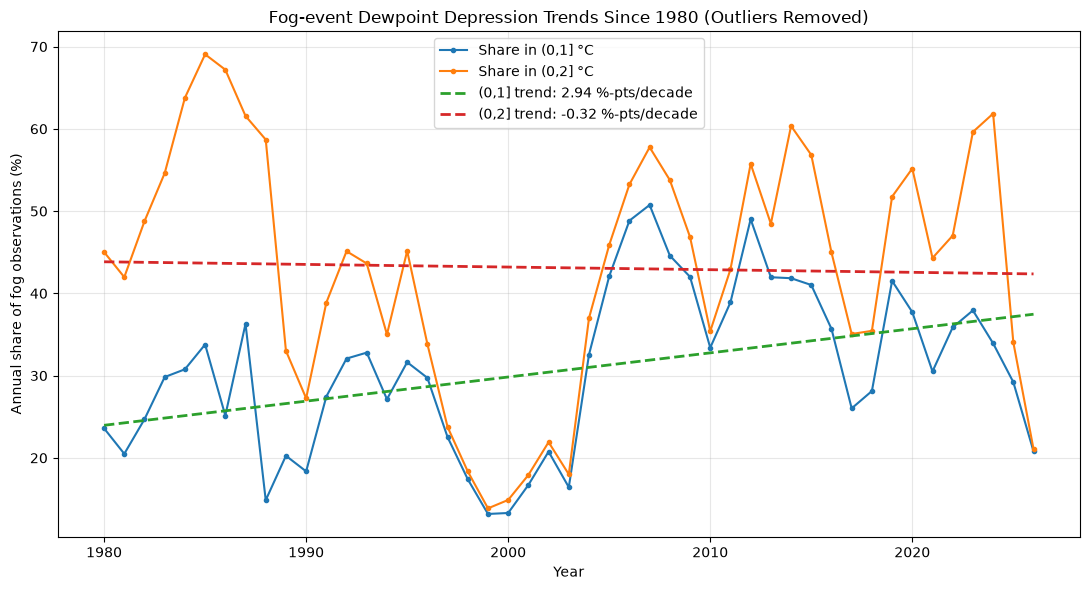


=== Station-level trend summary (>=10 years) ===
                       STATION  n_years  slope_pct01_per_year       p_pct01  \
22        VISALIA MUNICIPAL AP       21             -4.147523  6.567355e-05   
16       SACRAMENTO MATHER AFB       37             -0.637901  2.369435e-05   
17    SACRAMENTO MCCLELLAN AFB       32             -0.604223  1.232088e-04   
2                   CASTLE AFB       28             -0.054159  8.605139e-01   
1                    BEALE AFB       41              0.207074  4.438070e-01   
18  SACRAMENTO METROPOLITAN AP       42              0.200958  3.187396e-01   
6           LEMOORE REEVES NAS       46              0.828963  1.319269e-04   
5         HANFORD MUNICIPAL AP       22             -1.292527  2.034446e-02   
11                  MODESTO AP       47              0.064286  7.517759e-01   
4         FRESNO YOSEMITE INTL       47              0.731532  3.979575e-04   
7       LIVERMORE MUNICIPAL AP       27              0.223007  6.244347e-01   
15

In [37]:
# Since-1980 subset from outlier-filtered fog events
fog_dd_1980 = fog_dd_no_outliers.copy()
fog_dd_1980["DATE"] = pd.to_datetime(fog_dd_1980["DATE"], errors="coerce")
fog_dd_1980 = fog_dd_1980.dropna(subset=["DATE", "HourlyDewpointDepression"])
fog_dd_1980 = fog_dd_1980[fog_dd_1980["DATE"].dt.year >= 1980].copy()
fog_dd_1980["year"] = fog_dd_1980["DATE"].dt.year

# Indicators:
# (0,1] = dewpoint depression >0 and <=1
# (0,2] = dewpoint depression >0 and <=2
fog_dd_1980["dd_0_1"] = (
    (fog_dd_1980["HourlyDewpointDepression"] > 0) &
    (fog_dd_1980["HourlyDewpointDepression"] <= 1)
).astype(int)

fog_dd_1980["dd_0_2"] = (
    (fog_dd_1980["HourlyDewpointDepression"] > 0) &
    (fog_dd_1980["HourlyDewpointDepression"] <= 2)
).astype(int)

# Annual aggregate (all stations combined)
annual_dd = (
    fog_dd_1980.groupby("year", as_index=False)
    .agg(
        total_fog_obs=("HourlyDewpointDepression", "size"),
        n_dd_0_1=("dd_0_1", "sum"),
        n_dd_0_2=("dd_0_2", "sum")
    )
)

annual_dd["pct_dd_0_1"] = 100 * annual_dd["n_dd_0_1"] / annual_dd["total_fog_obs"]
annual_dd["pct_dd_0_2"] = 100 * annual_dd["n_dd_0_2"] / annual_dd["total_fog_obs"]

# Trend analysis (linear)
fit_01 = stats.linregress(annual_dd["year"], annual_dd["pct_dd_0_1"])
fit_02 = stats.linregress(annual_dd["year"], annual_dd["pct_dd_0_2"])

print("=== Since-1980 trend (all stations combined) ===")
print(f"(0,1] share slope: {fit_01.slope:.4f} %-points/year ({fit_01.slope*10:.3f} per decade), p={fit_01.pvalue:.4g}")
print(f"(0,2] share slope: {fit_02.slope:.4f} %-points/year ({fit_02.slope*10:.3f} per decade), p={fit_02.pvalue:.4g}")

# Plot annual shares + trend lines
x = annual_dd["year"].to_numpy()
y01 = annual_dd["pct_dd_0_1"].to_numpy()
y02 = annual_dd["pct_dd_0_2"].to_numpy()

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x, y01, marker="o", markersize=3, linewidth=1.5, label="Share in (0,1] °C")
ax.plot(x, y02, marker="o", markersize=3, linewidth=1.5, label="Share in (0,2] °C")

ax.plot(x, fit_01.intercept + fit_01.slope * x, linestyle="--", linewidth=2,
        label=f"(0,1] trend: {fit_01.slope*10:.2f} %-pts/decade")
ax.plot(x, fit_02.intercept + fit_02.slope * x, linestyle="--", linewidth=2,
        label=f"(0,2] trend: {fit_02.slope*10:.2f} %-pts/decade")

ax.set_title("Fog-event Dewpoint Depression Trends Since 1980 (Outliers Removed)")
ax.set_xlabel("Year")
ax.set_ylabel("Annual share of fog observations (%)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Optional station-level trend summary (shares), requiring >=10 years
station_year = (
    fog_dd_1980.groupby(["STATION", "year"], as_index=False)
    .agg(
        total=("HourlyDewpointDepression", "size"),
        n01=("dd_0_1", "sum"),
        n02=("dd_0_2", "sum")
    )
)
station_year["pct01"] = 100 * station_year["n01"] / station_year["total"]
station_year["pct02"] = 100 * station_year["n02"] / station_year["total"]

station_trends = []
for st, g in station_year.groupby("STATION"):
    if g["year"].nunique() < 10:
        continue
    g = g.sort_values("year")
    t01 = stats.linregress(g["year"], g["pct01"])
    t02 = stats.linregress(g["year"], g["pct02"])
    station_trends.append({
        "STATION": st,
        "n_years": g["year"].nunique(),
        "slope_pct01_per_year": t01.slope,
        "p_pct01": t01.pvalue,
        "sig_pct01": t01.pvalue < 0.05,
        "slope_pct02_per_year": t02.slope,
        "p_pct02": t02.pvalue,
        "sig_pct02": t02.pvalue < 0.05
    })

station_trends = pd.DataFrame(station_trends).sort_values("slope_pct02_per_year")
print("\n=== Station-level trend summary (>=10 years) ===")
print(station_trends)
print("\nSignificant station trends for (0,1] share (p<0.05):")
print(station_trends[station_trends["sig_pct01"]][["STATION", "slope_pct01_per_year", "p_pct01"]])
print("\nSignificant station trends for (0,2] share (p<0.05):")
print(station_trends[station_trends["sig_pct02"]][["STATION", "slope_pct02_per_year", "p_pct02"]])

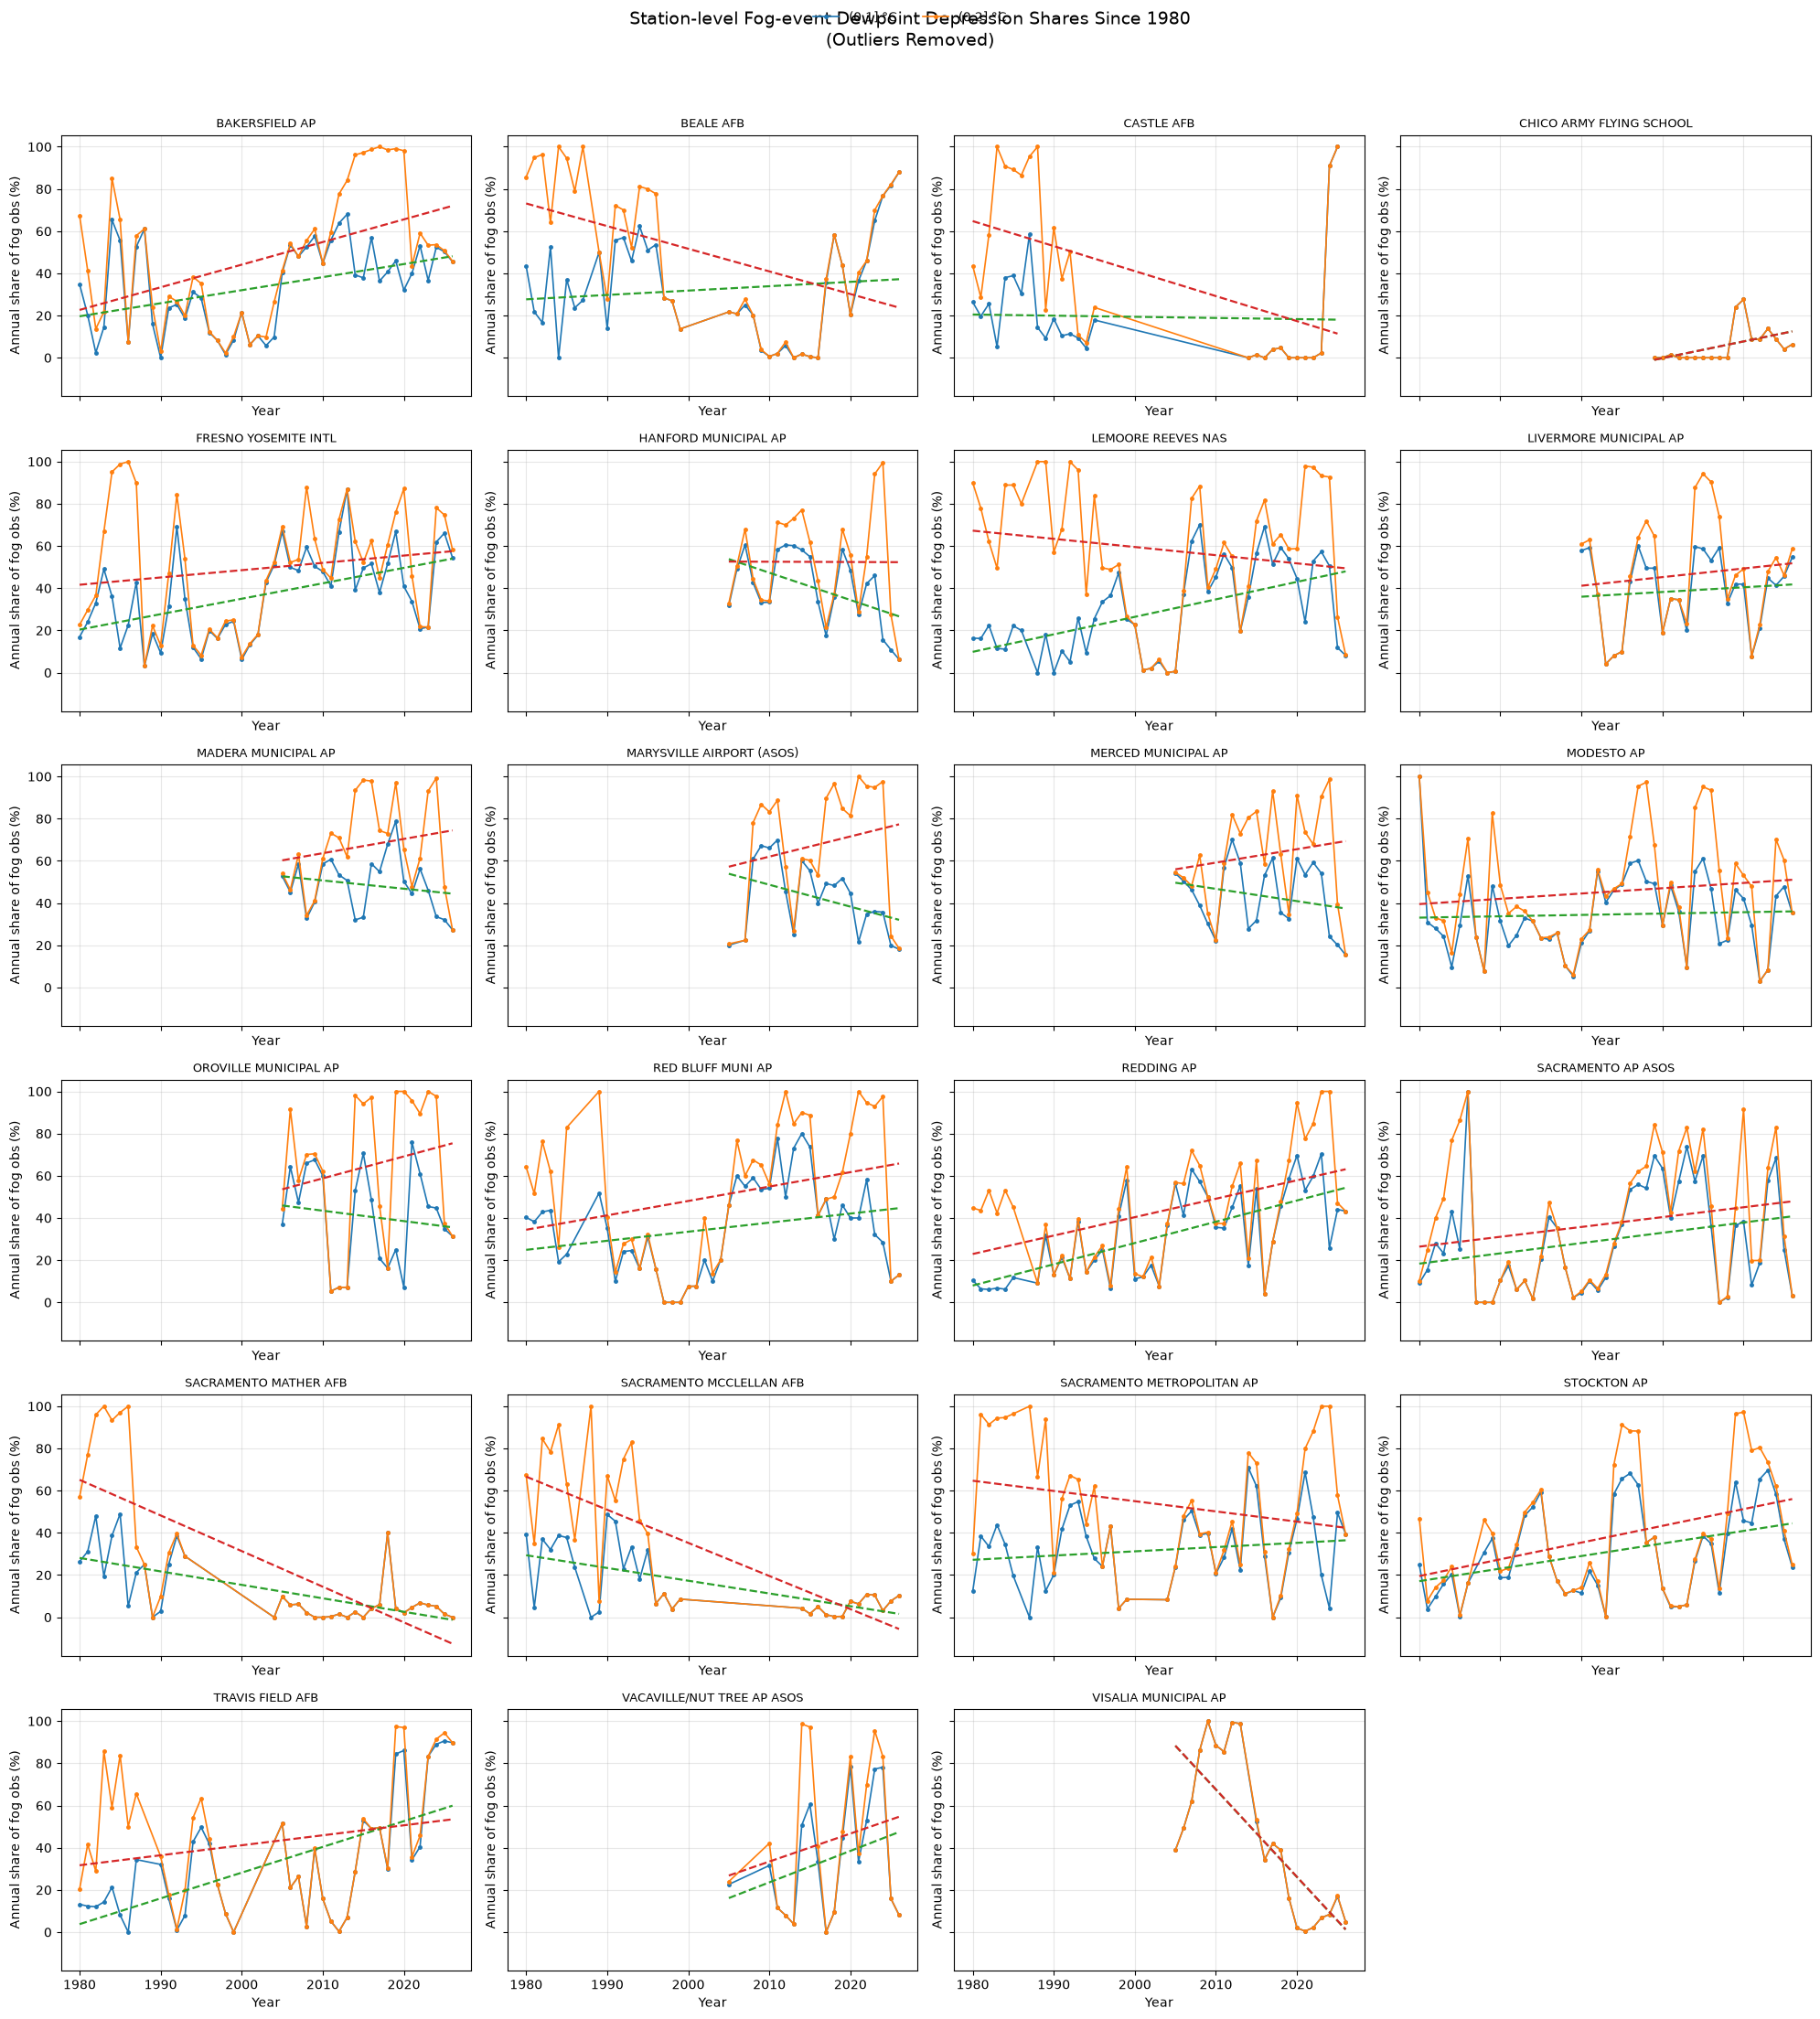

In [38]:
# Individual-station version of the annual_dd plot (since 1980, outliers removed)

# Reuse station_year if available; otherwise rebuild from fog_dd_1980
if "station_year" not in globals():
    station_year = (
        fog_dd_1980.groupby(["STATION", "year"], as_index=False)
        .agg(
            total=("HourlyDewpointDepression", "size"),
            n01=("dd_0_1", "sum"),
            n02=("dd_0_2", "sum")
        )
    )
    station_year["pct01"] = 100 * station_year["n01"] / station_year["total"]
    station_year["pct02"] = 100 * station_year["n02"] / station_year["total"]

# Keep stations with enough years for trends
min_years = 10
valid_counts = station_year.groupby("STATION")["year"].nunique()
stations_plot = sorted(valid_counts[valid_counts >= min_years].index)

n_stations = len(stations_plot)
if n_stations == 0:
    print(f"No stations with >= {min_years} years of data.")
else:
    ncols = 4
    nrows = int(np.ceil(n_stations / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.6 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    for i, stn in enumerate(stations_plot):
        ax = axes[i]
        g = station_year[station_year["STATION"] == stn].sort_values("year")

        x = g["year"].to_numpy()
        y01 = g["pct01"].to_numpy()
        y02 = g["pct02"].to_numpy()

        ax.plot(x, y01, marker="o", markersize=2.5, linewidth=1.2, label="(0,1] °C")
        ax.plot(x, y02, marker="o", markersize=2.5, linewidth=1.2, label="(0,2] °C")

        if g["year"].nunique() >= 2:
            fit01 = stats.linregress(x, y01)
            fit02 = stats.linregress(x, y02)
            ax.plot(x, fit01.intercept + fit01.slope * x, linestyle="--", linewidth=1.6)
            ax.plot(x, fit02.intercept + fit02.slope * x, linestyle="--", linewidth=1.6)

        ax.set_title(stn, fontsize=9)
        ax.set_xlabel("Year")
        ax.set_ylabel("Annual share of fog obs (%)")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

    fig.suptitle(
        "Station-level Fog-event Dewpoint Depression Shares Since 1980\n(Outliers Removed)",
        y=1.02,
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

                       STATION  n_years  slope_per_year  slope_per_decade  \
22        VISALIA MUNICIPAL AP       21       -0.042632         -0.426317   
16       SACRAMENTO MATHER AFB       37       -0.014586         -0.145863   
17    SACRAMENTO MCCLELLAN AFB       32       -0.013423         -0.134230   
1                    BEALE AFB       41       -0.012023         -0.120229   
2                   CASTLE AFB       28       -0.010129         -0.101289   
6           LEMOORE REEVES NAS       46       -0.007923         -0.079231   
18  SACRAMENTO METROPOLITAN AP       42       -0.005755         -0.057547   
7       LIVERMORE MUNICIPAL AP       27       -0.000329         -0.003291   
4         FRESNO YOSEMITE INTL       47        0.001272          0.012723   
5         HANFORD MUNICIPAL AP       22        0.001309          0.013089   
11                  MODESTO AP       47        0.003027          0.030273   
15          SACRAMENTO AP ASOS       47        0.003977          0.039769   

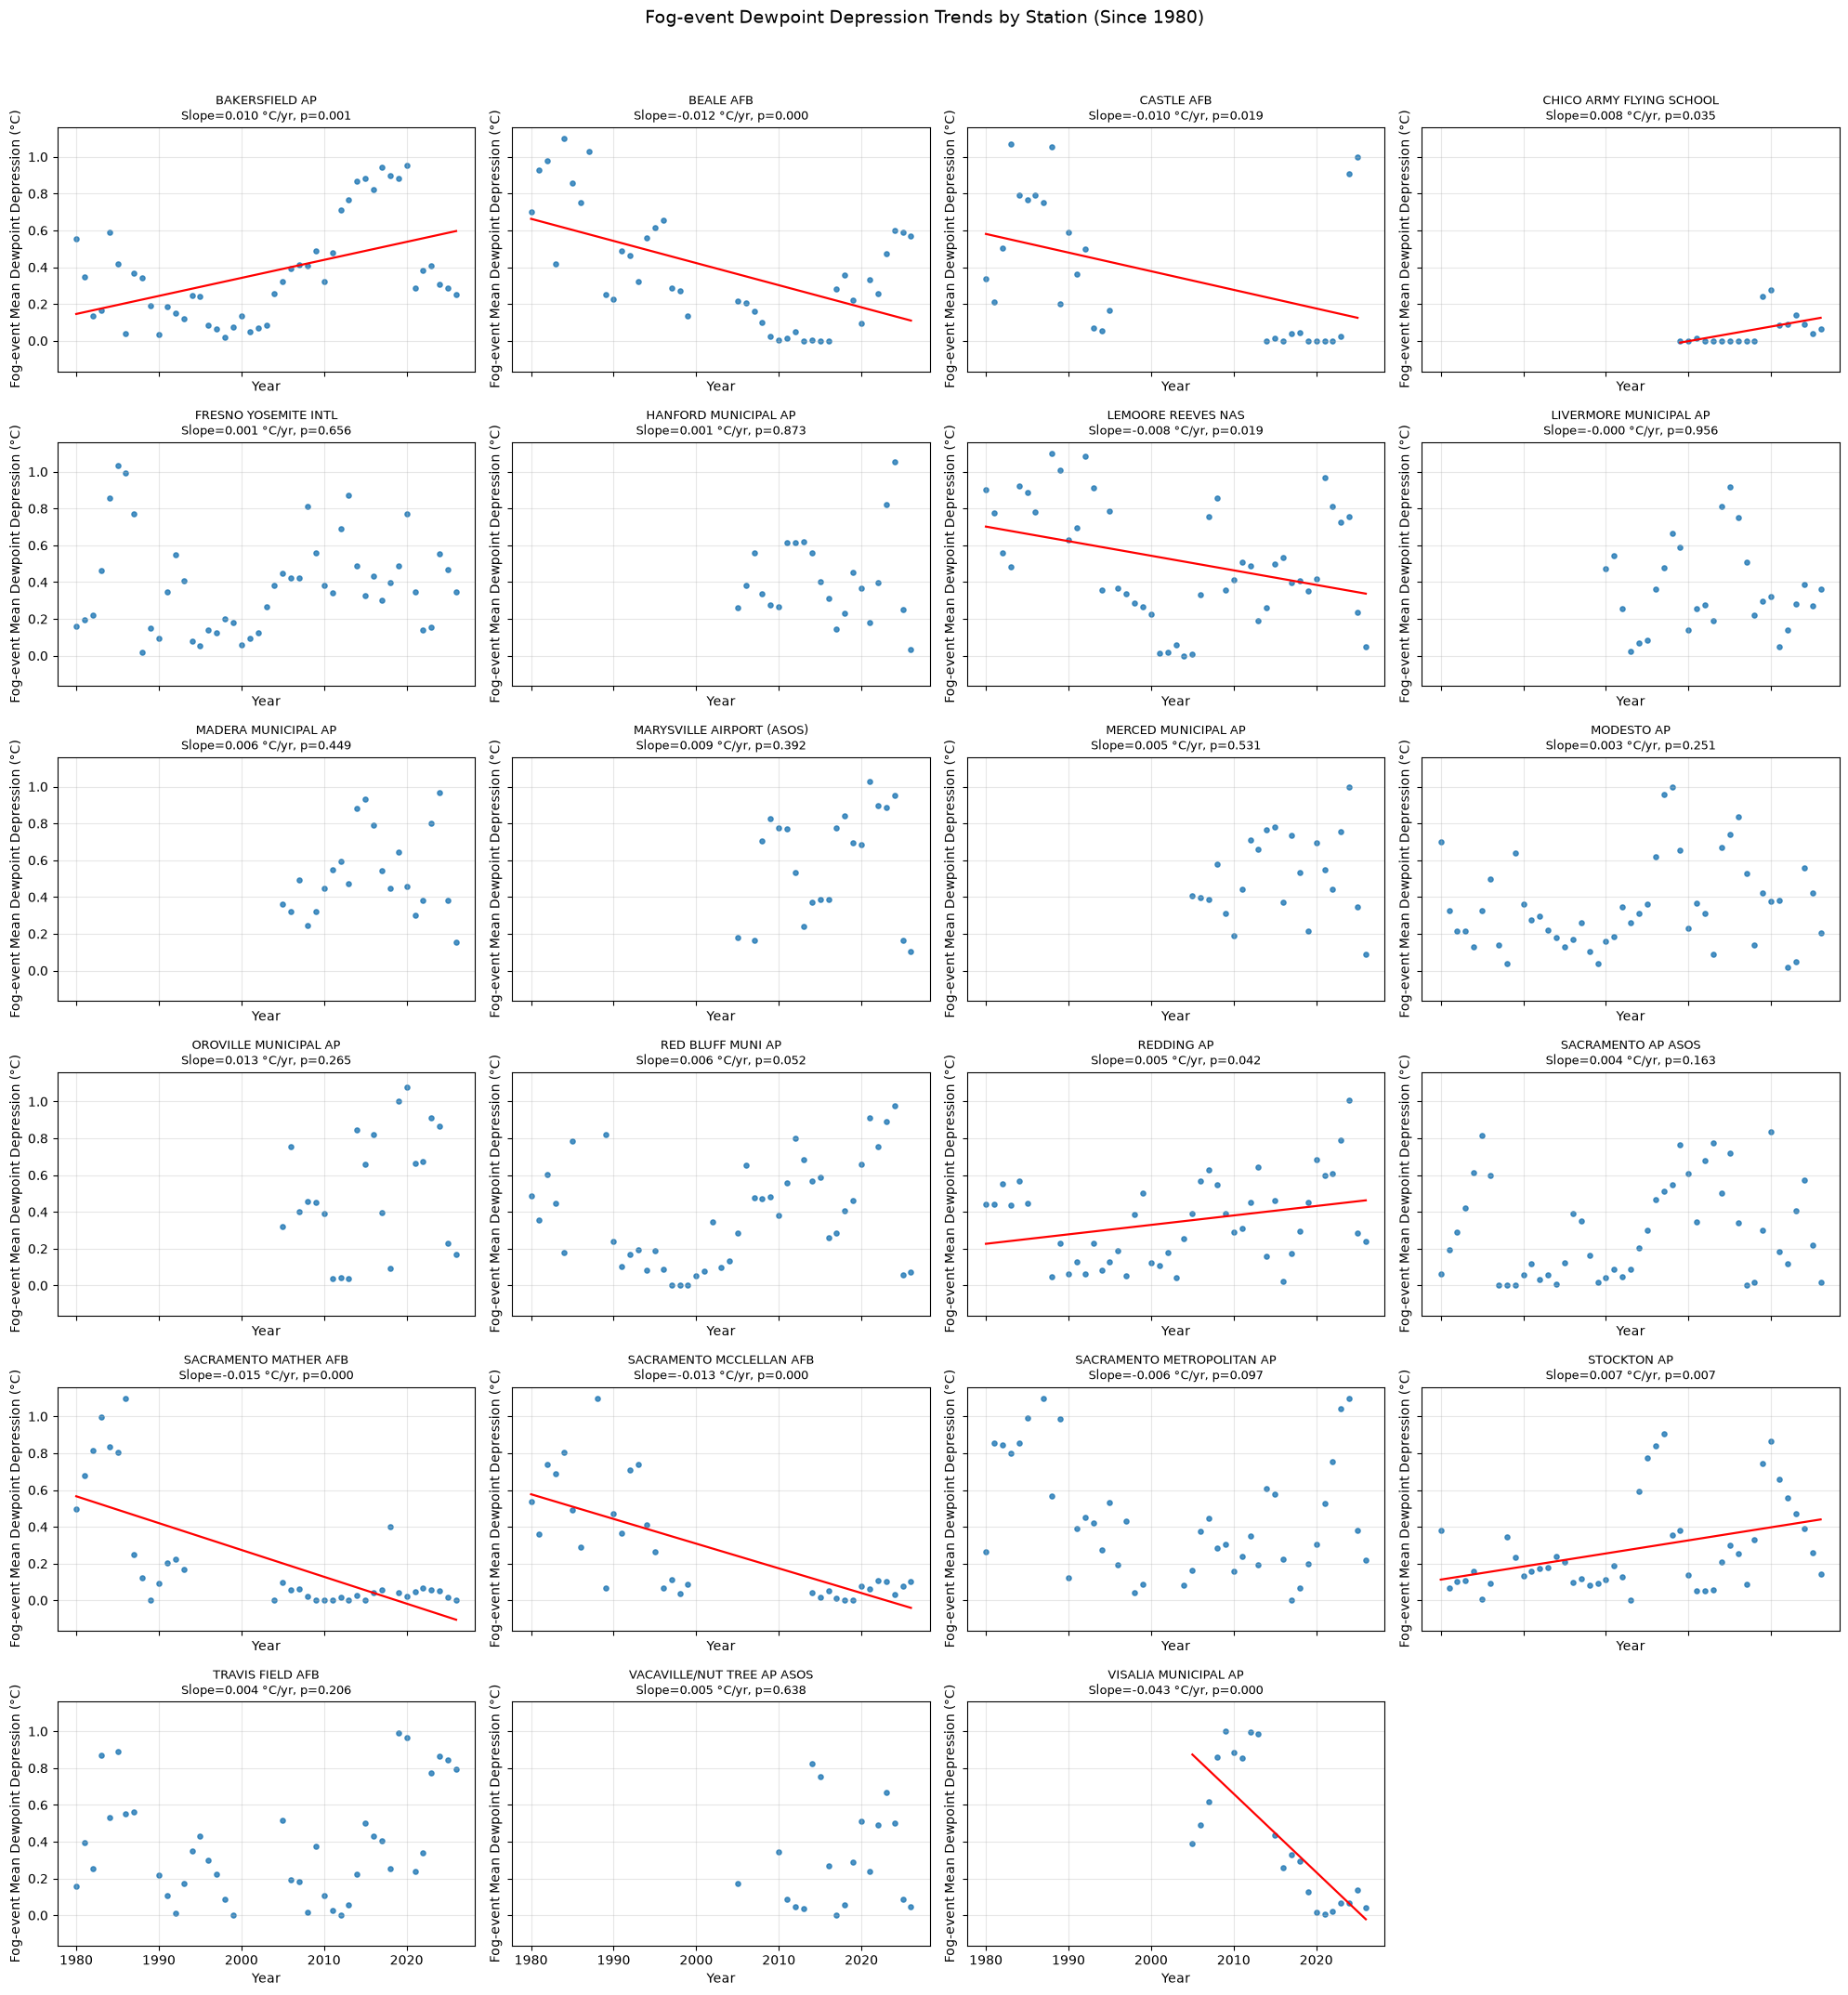

In [40]:
# Dewpoint depression trends for fog events (since 1980)

# Choose source dataframe
if "fog_dd_no_outliers" in globals():
    fog_trend_source = fog_dd_no_outliers.copy()
elif "fog_dd_df" in globals():
    fog_trend_source = fog_dd_df.copy()
else:
    fog_trend_source = CV_fog_rows.dropna(subset=["HourlyDewpointDepression"]).copy()

# Prepare time fields
fog_trend_source["DATE"] = pd.to_datetime(fog_trend_source["DATE"], errors="coerce")
fog_trend_source = fog_trend_source.dropna(subset=["DATE", "HourlyDewpointDepression"])
fog_trend_source = fog_trend_source[fog_trend_source["DATE"].dt.year >= 1980].copy()
fog_trend_source["year"] = fog_trend_source["DATE"].dt.year

# Annual mean dewpoint depression per station
fog_station_year = (
    fog_trend_source.groupby(["STATION", "year"], as_index=False)["HourlyDewpointDepression"]
    .mean()
)

# Keep stations with enough years
min_years = 10
counts = fog_station_year.groupby("STATION")["year"].nunique()
trend_stations = sorted(counts[counts >= min_years].index)

# Compute trends
trend_rows = []
for stn, g in fog_station_year[fog_station_year["STATION"].isin(trend_stations)].groupby("STATION"):
    g = g.sort_values("year")
    fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
    trend_rows.append({
        "STATION": stn,
        "n_years": g["year"].nunique(),
        "slope_per_year": fit.slope,
        "slope_per_decade": fit.slope * 10,
        "p_value": fit.pvalue,
        "r_value": fit.rvalue,
        "significant": fit.pvalue < 0.05
    })

fog_station_trends = pd.DataFrame(trend_rows).sort_values("slope_per_year")
print(fog_station_trends)

# Plot
n_stations = len(trend_stations)
if n_stations == 0:
    print(f"No stations with >= {min_years} years of fog-event data since 1980.")
else:
    ncols = 4
    nrows = int(np.ceil(n_stations / ncols))
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(5 * ncols, 3.5 * nrows),
        sharex=True, sharey=True
    )
    axes = np.array(axes).reshape(-1)

    for i, stn in enumerate(trend_stations):
        ax = axes[i]
        g = fog_station_year[fog_station_year["STATION"] == stn].sort_values("year")

        ax.scatter(g["year"], g["HourlyDewpointDepression"], s=14, alpha=0.8)

        fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
        x = np.array([g["year"].min(), g["year"].max()])
        # only plot the fitted line if the trend is significant at p<0.05
        if fit.pvalue < 0.05:
            y = fit.intercept + fit.slope * x
            ax.plot(x, y, color="red", linewidth=1.6)

        ax.set_title(f"{stn}\nSlope={fit.slope:.3f} °C/yr, p={fit.pvalue:.3f}", fontsize=9)
        ax.set_xlabel("Year")
        ax.set_ylabel("Fog-event Mean Dewpoint Depression (°C)")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Fog-event Dewpoint Depression Trends by Station (Since 1980)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

C:\Users\Work Account\AppData\Local\Temp\ipykernel_6548\3255663711.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


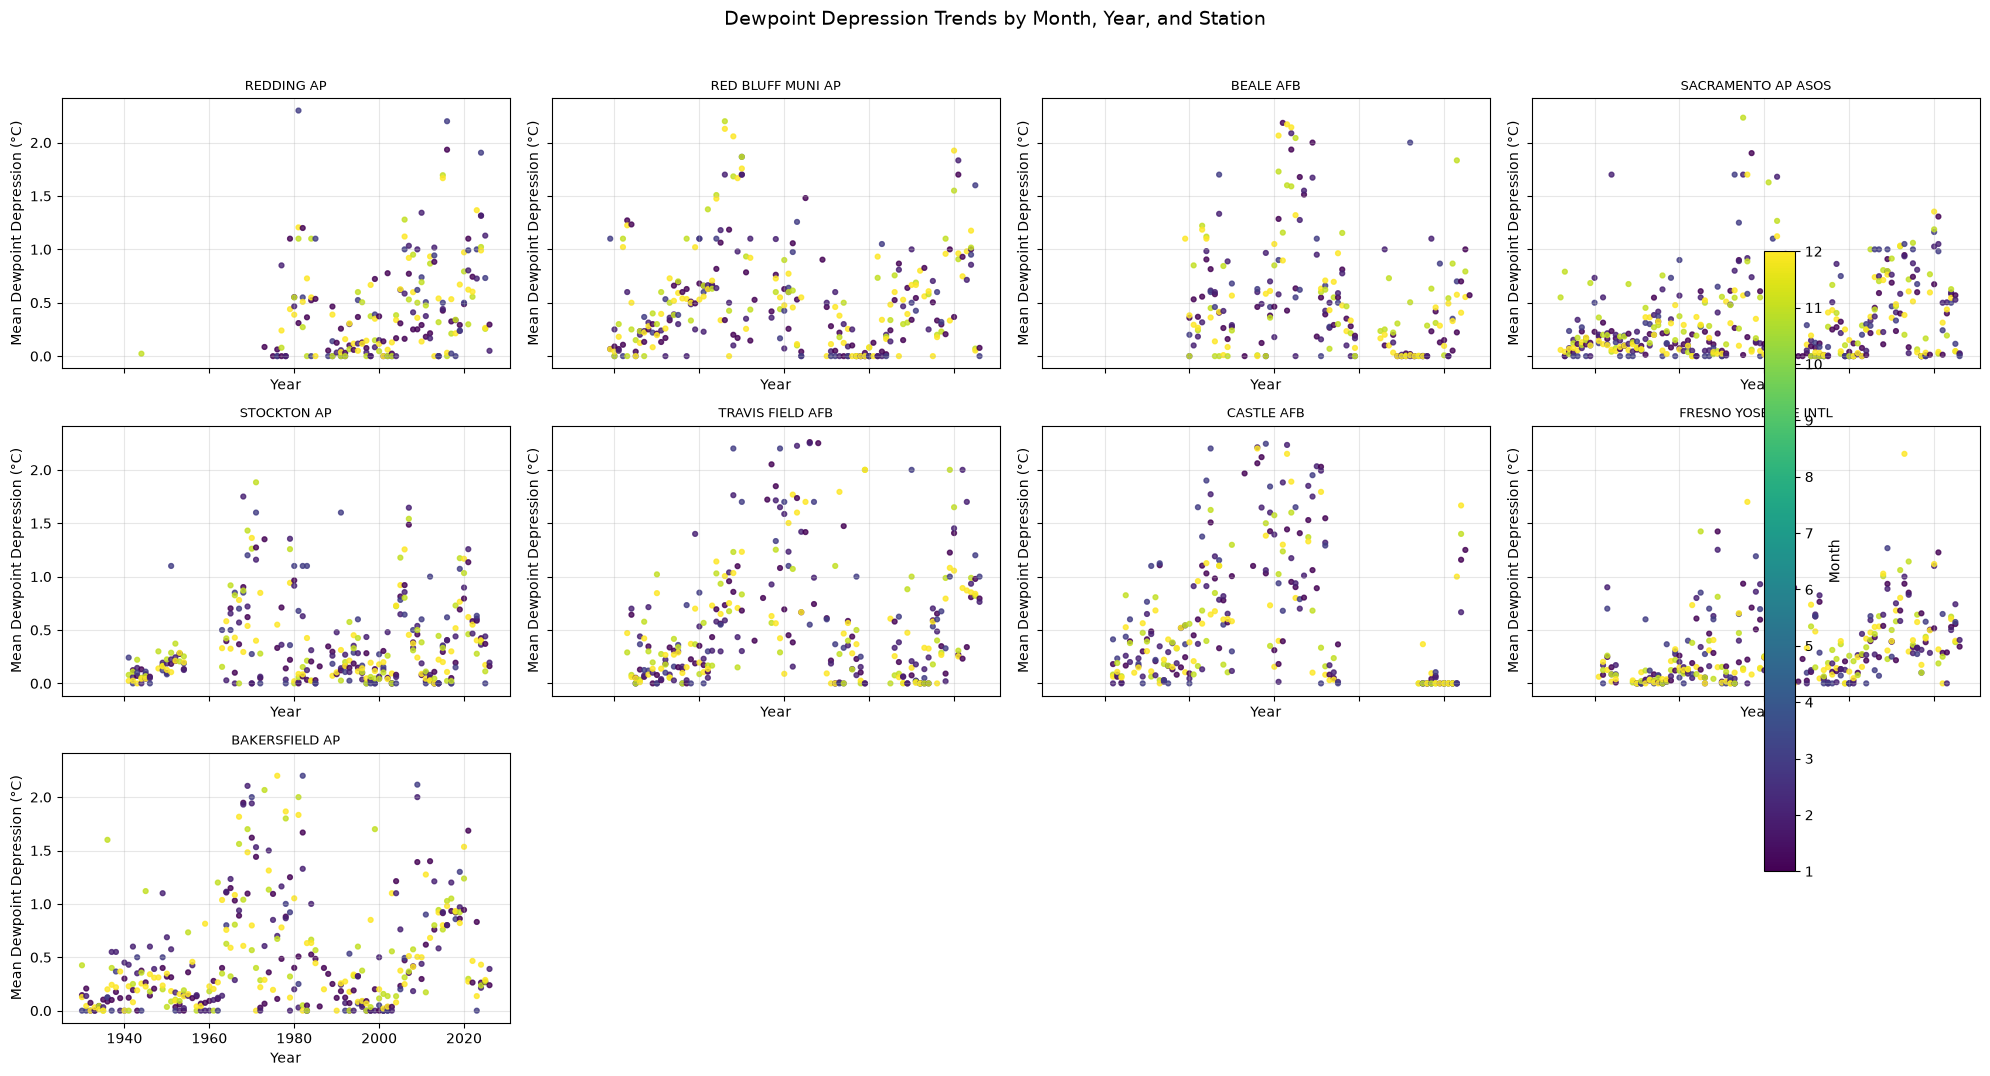

In [ ]:
# Monthly mean dewpoint depression by station/year/month
# need to only calculate dewpoint depression if the rows have both temperature and dewpoint values
# # filter out rows without both temperature and dewpoint values
# CV_rows = CV_rows.dropna(subset=["HourlyDryBulbTemperature", "HourlyDewPointTemperature"])


stations = ["REDDING AP", "RED BLUFF MUNI AP", "BEALE AFB", "SACRAMENTO AP ASOS", "STOCKTON AP", "TRAVIS FIELD AFB", "CASTLE AFB", "FRESNO YOSEMITE INTL", "BAKERSFIELD AP"]
n_stations = len(stations)

ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)
axes = np.array(axes).reshape(-1)

for i, station in enumerate(stations):
    ax = axes[i]
    sdata = monthly_station[monthly_station["STATION"] == station]

    ax.scatter(
        sdata["year"],
        sdata["HourlyDewpointDepression"],
        c=sdata["month"],
        cmap="viridis",
        vmin=1,
        vmax=12,
        s=12,
        alpha=0.8
    )
    ax.set_title(station, fontsize=9)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean Dewpoint Depression (°C)")
    ax.grid(alpha=0.3)

# Hide any unused subplot panels
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# Shared colorbar for month
smb = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=1, vmax=12))
smb.set_array([])
cbar = fig.colorbar(smb, ax=axes.tolist(), fraction=0.02, pad=0.01)
cbar.set_label("Month")
cbar.set_ticks(range(1, 13))

fig.suptitle("Dewpoint Depression Trends by Month, Year, and Station", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\Work Account\AppData\Local\Temp\ipykernel_3128\1739233258.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


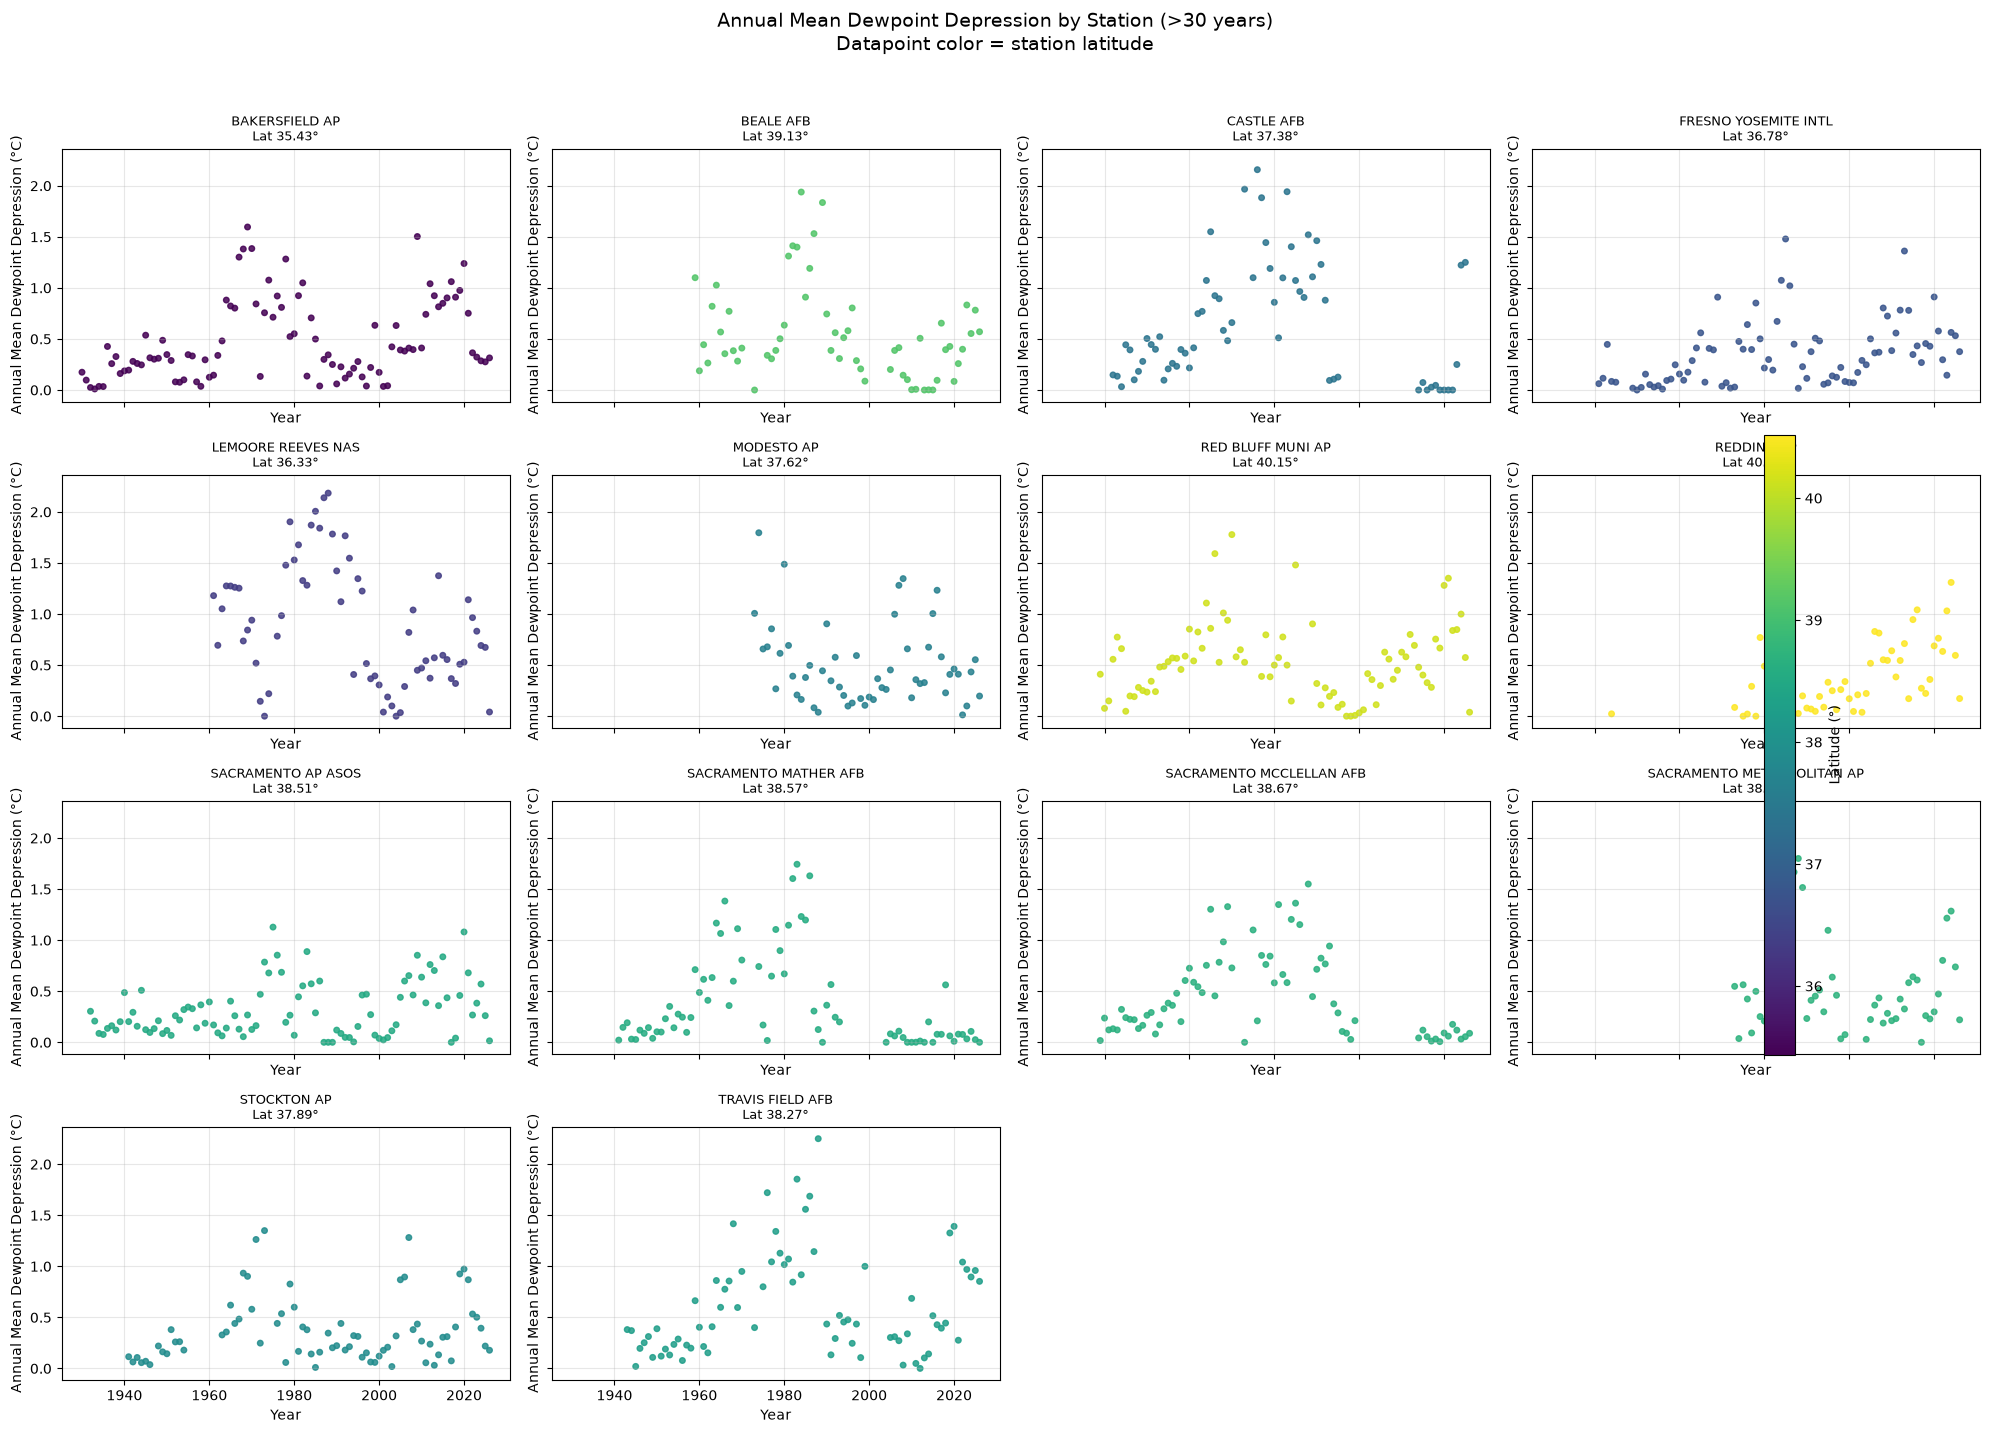

In [29]:
# # Annual mean dewpoint depression by station/year
# annual_station = (
#     monthly_station.groupby(["STATION", "year"], as_index=False)["HourlyDewpointDepression"]
#     .mean()
# )

# # Keep stations with >30 unique years of annual data
# year_counts = annual_station.groupby("STATION")["year"].nunique()
# eligible_stations_30 = year_counts[year_counts > 30].index

annual_station_30 = annual_station[annual_station["STATION"].isin(eligible_stations_30)].copy()

# Station latitude lookup
station_lat = (
    CV_rows[["STATION", "LATITUDE"]]
    .dropna()
    .groupby("STATION", as_index=True)["LATITUDE"]
    .median()
)

annual_station_30["LATITUDE"] = annual_station_30["STATION"].map(station_lat)

# Plot
stations_30 = sorted(annual_station_30["STATION"].dropna().unique())
n_stations_30 = len(stations_30)

if n_stations_30 == 0:
    print("No stations found with more than 30 years of data.")
else:
    ncols = 4
    nrows = int(np.ceil(n_stations_30 / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.5 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    lat_min = annual_station_30["LATITUDE"].min()
    lat_max = annual_station_30["LATITUDE"].max()
    norm = plt.Normalize(vmin=lat_min, vmax=lat_max)
    cmap = "viridis"

    for idx, station_name in enumerate(stations_30):
        ax = axes[idx]
        g = annual_station_30[annual_station_30["STATION"] == station_name].sort_values("year")
        lat_val = g["LATITUDE"].iloc[0]

        ax.scatter(
            g["year"],
            g["HourlyDewpointDepression"],
            c=np.full(len(g), lat_val),
            cmap=cmap,
            norm=norm,
            s=16,
            alpha=0.85
        )
        ax.set_title(f"{station_name}\nLat {lat_val:.2f}°", fontsize=9)
        ax.set_xlabel("Year")
        ax.set_ylabel("Annual Mean Dewpoint Depression (°C)")
        ax.grid(alpha=0.3)

    for idx in range(n_stations_30, len(axes)):
        axes[idx].axis("off")

    sma = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sma.set_array([])
    cbar = fig.colorbar(sma, ax=axes.tolist(), fraction=0.02, pad=0.01)
    cbar.set_label("Latitude (°)")

    fig.suptitle(
        "Annual Mean Dewpoint Depression by Station (>30 years)\nDatapoint color = station latitude",
        y=1.02,
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

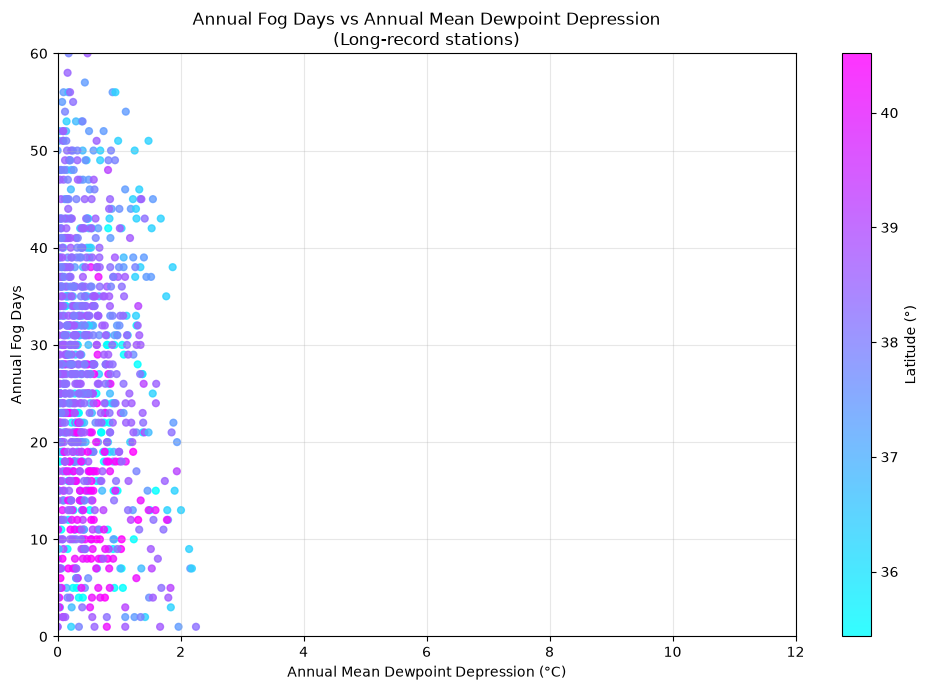

In [30]:
# Annual fog days (unique dates with fog) by station/year
fog_days_annual = (
    CV_fog_rows.assign(fog_date=pd.to_datetime(CV_fog_rows["DATE"], errors="coerce").dt.date)
    .dropna(subset=["fog_date"])
    .groupby(["STATION", "year"], as_index=False)["fog_date"]
    .nunique()
    .rename(columns={"fog_date": "annual_fog_days"})
)

# Keep only stations with long records (as defined above)
long_record_stations = set(eligible_stations_30)
fog_days_annual = fog_days_annual[fog_days_annual["STATION"].isin(long_record_stations)]

# Merge with annual mean dewpoint depression and latitude
plot_df = fog_days_annual.merge(
    annual_station_30[["STATION", "year", "HourlyDewpointDepression", "LATITUDE"]],
    on=["STATION", "year"],
    how="inner"
)

# Scatterplot: annual fog days vs annual mean dewpoint depression, colored by latitude
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    plot_df["HourlyDewpointDepression"],
    plot_df["annual_fog_days"],
    c=plot_df["LATITUDE"],
    cmap="cool",  # make colorbar blue to red for north to south
    s=24,
    alpha=0.8
)

plt.xlim(0,12)
plt.ylim(0,60)


ax.set_title("Annual Fog Days vs Annual Mean Dewpoint Depression\n(Long-record stations)")
ax.set_xlabel("Annual Mean Dewpoint Depression (°C)")
ax.set_ylabel("Annual Fog Days")
ax.grid(alpha=0.3)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Latitude (°)")

plt.tight_layout()
plt.show()

Rows before outlier removal: 990
Rows after outlier removal: 953
                            OLS Regression Results                            
Dep. Variable:        annual_fog_days   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     23.97
Date:                Wed, 12 Aug 2026   Prob (F-statistic):           6.96e-11
Time:                        14:45:12   Log-Likelihood:                -3749.8
No. Observations:                 953   AIC:                             7506.
Df Residuals:                     950   BIC:                             7520.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

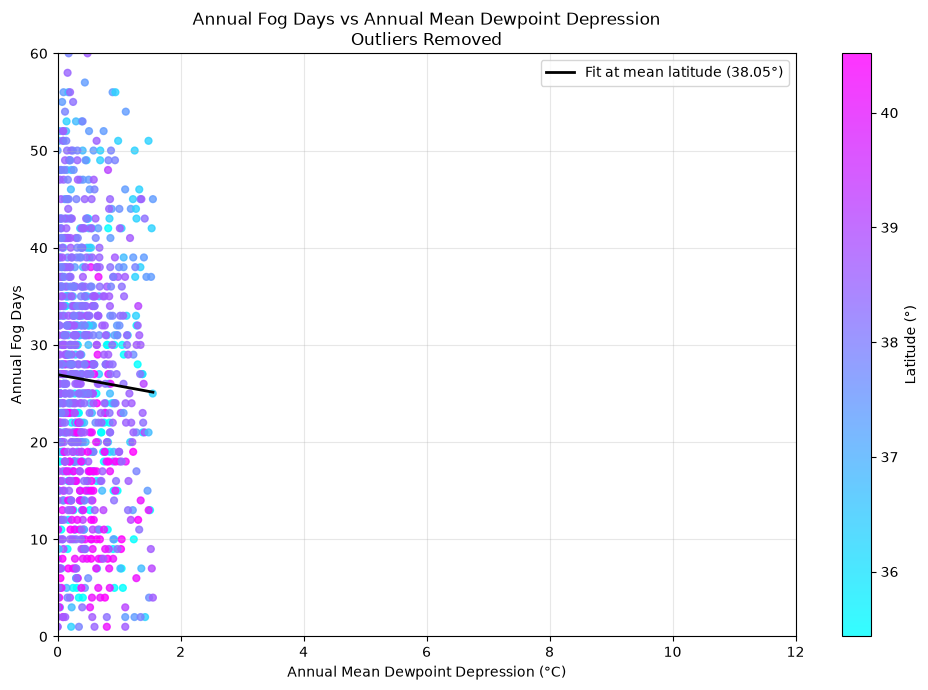

In [31]:
# Remove outliers from plot_df using the IQR rule and fit a linear model

clean_df = plot_df[["HourlyDewpointDepression", "annual_fog_days", "LATITUDE"]].dropna().copy()

for col in ["HourlyDewpointDepression", "annual_fog_days"]:
    q1 = clean_df[col].quantile(0.25)
    q3 = clean_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    clean_df = clean_df[(clean_df[col] >= lower) & (clean_df[col] <= upper)]

print("Rows before outlier removal:", len(plot_df))
print("Rows after outlier removal:", len(clean_df))

X_clean = sm.add_constant(clean_df[["HourlyDewpointDepression", "LATITUDE"]])
y_clean = clean_df["annual_fog_days"]

clean_model = sm.OLS(y_clean, X_clean).fit()
print(clean_model.summary())

lat_ref_clean = clean_df["LATITUDE"].mean()
dd_range_clean = np.linspace(
    clean_df["HourlyDewpointDepression"].min(),
    clean_df["HourlyDewpointDepression"].max(),
    100
)

pred_clean_df = pd.DataFrame({
    "const": 1.0,
    "HourlyDewpointDepression": dd_range_clean,
    "LATITUDE": lat_ref_clean
})
pred_clean_df["predicted_fog_days"] = clean_model.predict(pred_clean_df)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    clean_df["HourlyDewpointDepression"],
    clean_df["annual_fog_days"],
    c=clean_df["LATITUDE"],
    cmap="cool",
    s=24,
    alpha=0.8
)

ax.plot(
    pred_clean_df["HourlyDewpointDepression"],
    pred_clean_df["predicted_fog_days"],
    color="black",
    linewidth=2,
    label=f"Fit at mean latitude ({lat_ref_clean:.2f}°)"
)

plt.xlim(0,12)
plt.ylim(0,60)

ax.set_title("Annual Fog Days vs Annual Mean Dewpoint Depression\nOutliers Removed")
ax.set_xlabel("Annual Mean Dewpoint Depression (°C)")
ax.set_ylabel("Annual Fog Days")
ax.grid(alpha=0.3)
ax.legend()

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Latitude (°)")

plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:        annual_fog_days   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     30.59
Date:                Wed, 12 Aug 2026   Prob (F-statistic):           1.29e-13
Time:                        14:45:12   Log-Likelihood:                -3927.9
No. Observations:                 990   AIC:                             7862.
Df Residuals:                     987   BIC:                             7877.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

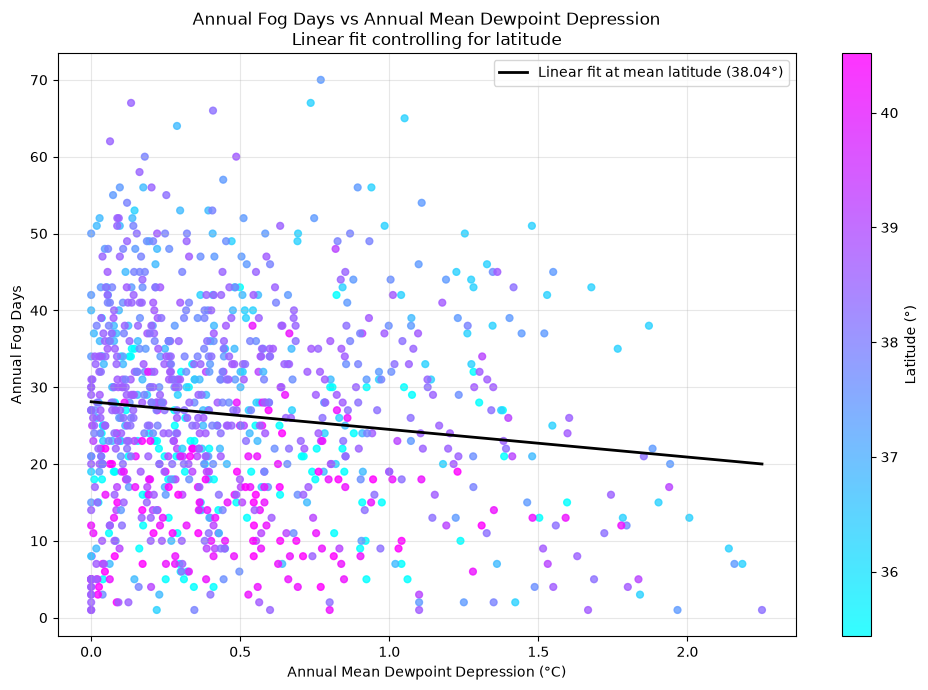

In [32]:
# Multiple linear regression: annual fog days as a function of
# annual mean dewpoint depression and latitude
X_fit = sm.add_constant(plot_df[["HourlyDewpointDepression", "LATITUDE"]])
y_fit = plot_df["annual_fog_days"]

fog_dd_lat_model = sm.OLS(y_fit, X_fit).fit()
print(fog_dd_lat_model.summary())

# Predicted relationship at mean latitude
lat_ref_fit = plot_df["LATITUDE"].mean()
dd_range_fit = np.linspace(
    plot_df["HourlyDewpointDepression"].min(),
    plot_df["HourlyDewpointDepression"].max(),
    100
)

pred_fit_df = pd.DataFrame({
    "const": 1.0,
    "HourlyDewpointDepression": dd_range_fit,
    "LATITUDE": lat_ref_fit
})
pred_fit_df["predicted_fog_days"] = fog_dd_lat_model.predict(pred_fit_df)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    plot_df["HourlyDewpointDepression"],
    plot_df["annual_fog_days"],
    c=plot_df["LATITUDE"],
    cmap="cool",
    s=24,
    alpha=0.8
)

ax.plot(
    pred_fit_df["HourlyDewpointDepression"],
    pred_fit_df["predicted_fog_days"],
    color="black",
    linewidth=2,
    label=f"Linear fit at mean latitude ({lat_ref_fit:.2f}°)"
)

ax.set_title("Annual Fog Days vs Annual Mean Dewpoint Depression\nLinear fit controlling for latitude")
ax.set_xlabel("Annual Mean Dewpoint Depression (°C)")
ax.set_ylabel("Annual Fog Days")
ax.grid(alpha=0.3)
ax.legend()

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Latitude (°)")

plt.tight_layout()
plt.show()